In [119]:
# ============================================================================
# IMPORTS
# ============================================================================

# Standard Library
import os
import glob
import json
import yaml
import time
import math
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict

# Data Science & Visualization
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing
import librosa
from pydub import AudioSegment
from scipy.signal import butter, lfilter

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
from torch.utils.tensorboard import SummaryWriter

# Metrics (Scikit-Learn)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support
)

# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

# Suppress Warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Global Constants
SUPPORTED_EXTS = (".wav", ".mp3", ".m4a", ".wma")
RANDOM_SEED = 42

# Reproducibility
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ============================================================================
# PATHS
# ============================================================================

# Determine Base Directory
# If running as a script, use __file__; otherwise (notebook), use cwd
BASE_DIR = Path(__file__).parent if '__file__' in globals() else Path.cwd()

# Define Data and Output Directories
# Notebook is likely inside IML-PW, so check local folders first
data_root = BASE_DIR / "Recordings_1"
output_dir = BASE_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Fallback path logic
if not data_root.exists():
    alt = BASE_DIR.parent / "IML-PW" / "Recordings"
    if alt.exists():
        print(f"⚠️ Using fallback data_root: {alt}")
        data_root = alt
    else:
        raise FileNotFoundError(f"Recordings folder not found. Checked: {data_root} and {alt}")

print(f"📁 data_root: {data_root}")
print(f"📁 output_dir: {output_dir}")

# ============================================================================
# LABELING MODE SELECTION
# ============================================================================
# Choose ONE of the following modes:
#
# "binary"     - Labels: 0 (outsider), 1 (group member)
#                Use case: Simple access control (allowed vs not allowed)
#                Model output: 2 classes
#
# "speaker_id" - Labels: 0, 1, 2, 3, ... (unique speaker IDs)
#                Use case: Speaker identification + access control via embeddings
#                Model output: N classes (one per speaker)
#                Recommended for: Identifying WHO is speaking + access control
# ============================================================================

LABEL_MODE = "binary"  # Options: "binary" or "speaker_id"

print(f"\n🏷️  LABEL MODE: {LABEL_MODE}")
if LABEL_MODE == "binary":
    print("   → Labels: 0=outsider, 1=group member")
    print("   → Model: Binary classification (2 classes)")
elif LABEL_MODE == "speaker_id":
    print("   → Labels: Unique speaker IDs (0, 1, 2, ...)")
    print("   → Model: Multi-class speaker recognition + embedding verification")

# ============================================================================
# HYPERPARAMETERS
# ============================================================================

# Audio / Feature Params
sr = 16000
n_mels = 64
n_fft = 2048
hop_length = 512
chunk_duration = 1.0  # seconds

# Augmentation Toggles
WITH_NOISE = True
WITH_SPEED = True
WITH_VTLP = True
WITH_SPECTRAL = True

AGGRESIVE_AUG_CLASS_1 = True

📁 data_root: c:\Users\pczec\Desktop\Studia\SEM5\IML\IML-PW\Recordings_1
📁 output_dir: c:\Users\pczec\Desktop\Studia\SEM5\IML\IML-PW\outputs

🏷️  LABEL MODE: binary
   → Labels: 0=outsider, 1=group member
   → Model: Binary classification (2 classes)


In [120]:
# ==========================================================
# INFERENCE-COMPATIBLE PREPROCESSING CLASS
# ==========================================================
from scipy.signal import butter, lfilter
from pydub import AudioSegment


class AudioPreprocessor:
    """Lightweight preprocessing pipeline."""
    def __init__(self, sr=16000, n_mels=64, n_fft=2048, hop_length=512,
                 chunk_duration=3.0, remove_silence=True, normalize=True,
                 lowcut=None, highcut=None, filter_order=4):
        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.chunk_duration = chunk_duration
        self.remove_silence = remove_silence
        self.normalize = normalize
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

    def load_audio(self, path):
        """Load and resample audio."""
        audio = AudioSegment.from_file(path)
        if audio.channels > 1:
            audio = audio.set_channels(1)

        samples = np.array(audio.get_array_of_samples()).astype(np.float32)
        samples /= (1 << (8 * audio.sample_width - 1))

        if audio.frame_rate != self.sr:
            samples = librosa.resample(samples, orig_sr=audio.frame_rate, target_sr=self.sr)

        return samples

    def trim_silence(self, samples, top_db=30):
        """Remove silence from audio."""
        non_silent, _ = librosa.effects.trim(samples, top_db=top_db)
        return non_silent

    def normalize_volume(self, samples):
        """Normalize audio volume."""
        max_val = np.max(np.abs(samples)) + 1e-9
        return samples / max_val

    def apply_filter(self, samples):
        """Apply Butterworth filter."""
        if not self.lowcut and not self.highcut:
            return samples

        nyq = 0.5 * self.sr
        if self.lowcut and self.highcut:
            b, a = butter(self.filter_order, [self.lowcut / nyq, self.highcut / nyq], btype="band")
        elif self.lowcut:
            b, a = butter(self.filter_order, self.lowcut / nyq, btype="high")
        else:
            b, a = butter(self.filter_order, self.highcut / nyq, btype="low")

        return lfilter(b, a, samples)

    def chunk_audio(self, samples):
        """Split audio into fixed-length chunks."""
        chunk_len = int(self.chunk_duration * self.sr)
        chunks = []

        for i in range(0, len(samples), chunk_len):
            chunk = samples[i:i + chunk_len]
            if len(chunk) < chunk_len:
                pad = np.zeros(chunk_len, dtype=samples.dtype)
                pad[:len(chunk)] = chunk
                chunk = pad
            chunks.append(chunk)

        return chunks


    def to_logmel(self, samples):
        """Convert audio to log-mel spectrogram."""
        mel = librosa.feature.melspectrogram(
            y=samples, sr=self.sr, n_mels=self.n_mels,
            n_fft=self.n_fft, hop_length=self.hop_length
        )
        logmel = librosa.power_to_db(mel, ref=np.max)
        return logmel.astype(np.float32)

    def get_config(self):
        """Return configuration dict."""
        return {
            "sr": self.sr,
            "n_mels": self.n_mels,
            "n_fft": self.n_fft,
            "hop_length": self.hop_length,
            "chunk_duration": self.chunk_duration,
            "remove_silence": self.remove_silence,
            "normalize": self.normalize,
            "lowcut": self.lowcut,
            "highcut": self.highcut,
            "filter_order": self.filter_order
        }


# ==========================================================
# AUGMENTATION FUNCTIONS
# ==========================================================
def add_ambient_noise(samples, noise_factor=0.005):
    """Add Gaussian noise."""
    noise = np.random.randn(len(samples)) * noise_factor
    return samples + noise


def speed_perturbation(samples, sr, speed_factor=1.0):
    """Apply time stretching."""
    return librosa.effects.time_stretch(samples, rate=speed_factor)


def spectral_augmentation(logmel, freq_mask_param=10, time_mask_param=20, n_masks=2):
    """Apply SpecAugment-style masking."""
    augmented = logmel.copy()
    n_mels, n_frames = augmented.shape

    for _ in range(n_masks):
        f = np.random.randint(0, min(freq_mask_param, n_mels))
        f0 = np.random.randint(0, max(1, n_mels - f))
        augmented[f0:f0+f, :] = augmented.mean()

    for _ in range(n_masks):
        t = np.random.randint(0, min(time_mask_param, n_frames))
        t0 = np.random.randint(0, max(1, n_frames - t))
        augmented[:, t0:t0+t] = augmented.mean()

    return augmented


def vocal_tract_length_perturbation(samples, sr, alpha=1.0):
    """Apply VTLP via frequency warping."""
    D = librosa.stft(samples)
    n_fft = (D.shape[0] - 1) * 2
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    warped_freqs = freqs * alpha

    D_warped = np.zeros_like(D)
    for i, wf in enumerate(warped_freqs):
        if wf < freqs[-1]:
            idx = np.searchsorted(freqs, wf)
            if idx < len(freqs) - 1:
                D_warped[i] = D[idx]

    return librosa.istft(D_warped, length=len(samples))

In [121]:
# Helpers: YAML parsing and speaker mapping

def parse_labels_yaml(yaml_path):
    if not yaml_path.exists():
        return {}
    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f) or {}
    
    def coerce_entry(value, default_speaker):
        """Convert various YAML formats to (gender, in_group, speaker_name)."""
        if isinstance(value, (list, tuple)) and len(value) >= 3:
            gender, in_group, speaker_name = value[0], bool(value[1]), value[2]
            return gender, in_group, speaker_name
        if isinstance(value, dict):
            return (
                value.get("gender", "Unknown"),
                bool(value.get("in_group", False)),
                value.get("speaker_name", default_speaker),
            )
        if isinstance(value, str):
            cleaned = value.strip()
            if cleaned.startswith("(") and cleaned.endswith(")"):
                cleaned = cleaned[1:-1]
            parts = [p.strip() for p in cleaned.split(",")]
            if len(parts) >= 3:
                gender = parts[0]
                in_group_raw = parts[1].lower()
                in_group = in_group_raw in {"true", "1", "yes"}
                speaker_name = parts[2]
                return gender, in_group, speaker_name
        return None
    
    parsed = {}
    for filename, value in data.items():
        coerced = coerce_entry(value, yaml_path.parent.name)
        if coerced:
            gender, in_group, speaker_name = coerced
            parsed[filename] = {
                "gender": gender,
                "in_group": in_group,
                "speaker_name": speaker_name,
            }
    return parsed


def collect_speaker_info(root: Path):
    """Collect all unique speakers from YAML files for metadata purposes."""
    speakers = set()
    for folder in root.iterdir():
        if not folder.is_dir():
            continue
        meta = parse_labels_yaml(folder / "labels.yaml")
        for info in meta.values():
            speakers.add(info["speaker_name"])
    return sorted(speakers)


In [122]:
# Audio processing and augmentations

def load_audio(path: Path):
    """Robust audio loader: try soundfile, then librosa (warning-suppressed)."""
    # 1) Try soundfile (fast for WAV/FLAC/OGG)
    try:
        import soundfile as sf
        samples, file_sr = sf.read(str(path), always_2d=False)
        if samples.ndim > 1:
            samples = samples.mean(axis=1)
        samples = samples.astype(np.float32, copy=False)
        return samples, int(file_sr)
    except Exception:
        pass

    # 2) Fallback to librosa with audioread backend; suppress future warning
    import warnings as _warnings
    with _warnings.catch_warnings():
        _warnings.filterwarnings("ignore", category=FutureWarning, module="librosa.core.audio")
        samples, file_sr = librosa.load(str(path), sr=None, mono=True)
    samples = samples.astype(np.float32, copy=False)
    return samples, int(file_sr)


def resample_if_needed(samples, file_sr):
    if file_sr == sr:
        return samples
    return librosa.resample(samples, orig_sr=file_sr, target_sr=sr)


# def chunk_audio(samples):
#     chunk_len = int(chunk_duration * sr)
#     chunks = []
#     for i in range(0, len(samples), chunk_len):
#         chunk = samples[i : i + chunk_len]
#         if len(chunk) < chunk_len:
#             pad = np.zeros(chunk_len, dtype=chunk.dtype)
#             pad[: len(chunk)] = chunk
#             chunk = pad
#         chunks.append(chunk)
#     return chunks

        
def chunk_audio(samples, overlap=0.0):
    """
    Split audio into fixed-length chunks with optional overlap.
    overlap: Float between 0.0 and 0.99 (e.g., 0.8 = 80% overlap = 5x more chunks).
    """
    chunk_len = int(chunk_duration * sr)
    
    # Calculate step size (stride) based on overlap
    # If overlap is 0, stride is full chunk_len (standard).
    # If overlap is 0.8, stride is 20% of chunk_len (5x more chunks).
    stride = int(chunk_len * (1 - overlap))
    
    chunks = []
    
    # Handle files shorter than one chunk
    if len(samples) < chunk_len:
        pad = np.zeros(chunk_len, dtype=samples.dtype)
        pad[:len(samples)] = samples
        chunks.append(pad)
    else:
        # Sliding window
        # We stop early to avoid creating a tiny partial chunk at the end
        for i in range(0, len(samples) - chunk_len + 1, stride):
            chunk = samples[i : i + chunk_len]
            chunks.append(chunk)
        
    return chunks


def to_logmel(chunk):
    mel = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


# def add_noise(samples):
#     noise_factor = np.random.uniform(0.002, 0.008)
#     return samples + np.random.randn(len(samples)) * noise_factor, f"noise_{noise_factor:.4f}"

def add_noise(samples, level="low"):
    """
    Add Gaussian noise.
    level: 'low' (standard) or 'high' (stress test for Class 1)
    """
    if level == "high":
        # Aggressive noise (0.015 to 0.03 amplitude) - Loud!
        noise_factor = np.random.uniform(0.015, 0.03) 
        tag = f"noise_high_{noise_factor:.3f}"
    else:
        # Standard background hiss (0.002 to 0.008)
        noise_factor = np.random.uniform(0.002, 0.008)
        tag = f"noise_low_{noise_factor:.4f}"
        
    noise = np.random.randn(len(samples)) * noise_factor
    return samples + noise, tag


def speed_perturb(samples, factor):
    return librosa.effects.time_stretch(samples, rate=factor), f"speed_{factor:.2f}"


def vtlp_stub(samples, alpha):
    """
    Wrapper to apply Vocal Tract Length Perturbation.
    Actually calls the vocal_tract_length_perturbation function.
    """
    try:
        # Call the heavy implementation defined in the cell above
        augmented = vocal_tract_length_perturbation(samples, sr, alpha)
        return augmented, f"vtlp_{alpha:.2f}"
    except Exception as e:
        # Fallback if VTLP fails (e.g. on very short silence)
        return samples, "original"


def spectral_mask(logmel):
    lm = logmel.copy()
    n_m, n_t = lm.shape
    for _ in range(2):
        f = np.random.randint(0, min(10, n_m))
        f0 = np.random.randint(0, max(1, n_m - f))
        lm[f0 : f0 + f, :] = lm.mean()
    for _ in range(2):
        t = np.random.randint(0, min(20, n_t))
        t0 = np.random.randint(0, max(1, n_t - t))
        lm[:, t0 : t0 + t] = lm.mean()
    return lm

In [123]:
# Parallelized data collection using joblib
# ============================================================================
# APPROACH 2: Speaker ID labels + in_group metadata for embedding-based verification
# ============================================================================

from joblib import Parallel, delayed

def build_speaker_to_id(root: Path):
    """Build consistent speaker_name -> speaker_id mapping from all YAML files."""
    all_speakers = set()
    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        meta = parse_labels_yaml(folder / "labels.yaml")
        for info in meta.values():
            all_speakers.add(info["speaker_name"])
    
    # Sort for reproducibility, assign IDs
    sorted_speakers = sorted(all_speakers)
    speaker_to_id = {name: idx for idx, name in enumerate(sorted_speakers)}
    id_to_speaker = {idx: name for name, idx in speaker_to_id.items()}
    
    return speaker_to_id, id_to_speaker


def process_single_file(file_path: Path, meta: dict, in_group: bool, speaker_name: str, speaker_id: int):
    """Process a single audio file and return all chunks with augmentations.
    
    Returns list of tuples: (spec, label, aug_tag, is_vtlp, spk_info, file_path_str)
    
    Label type depends on LABEL_MODE:
    - "binary":     label = 1 (in_group) or 0 (outsider)
    - "speaker_id": label = speaker_id (0, 1, 2, ...)
    """
    results = []
    
    try:
        # Load and preprocess audio
        samples, file_sr = load_audio(file_path)
        samples = resample_if_needed(samples, file_sr)
        
        # Choose label based on LABEL_MODE
        if LABEL_MODE == "binary":
            label = 1 if in_group else 0
        else:  # speaker_id mode
            label = speaker_id
        
        # Store both speaker_name and in_group for inference-time access control
        spk_info = {
            "speaker_id": speaker_id,
            "speaker_name": speaker_name, 
            "in_group": in_group
        }
        file_path_str = str(file_path)
        
        # Create chunks from original audio
        chunks = chunk_audio(samples)
        
        for chunk in chunks:
            # Original
            spec = to_logmel(chunk)
            results.append((spec, label, "original", False, spk_info, file_path_str))
            
            # Noise augmentation
            if WITH_NOISE:
                noisy, tag = add_noise(chunk)
                spec_noisy = to_logmel(noisy)
                results.append((spec_noisy, label, tag, False, spk_info, file_path_str))
            
            # Spectral augmentation (applied to spectrogram)
            if WITH_SPECTRAL:
                spec_masked = spectral_mask(spec)
                results.append((spec_masked, label, "spectral_mask", False, spk_info, file_path_str))
        
        # Speed perturbation (changes chunk count, process separately)
        if WITH_SPEED:
            for speed_factor in [0.9, 1.1]:
                try:
                    sped, tag = speed_perturb(samples, speed_factor)
                    sped_chunks = chunk_audio(sped)
                    for chunk in sped_chunks:
                        spec = to_logmel(chunk)
                        results.append((spec, label, tag, False, spk_info, file_path_str))
                except Exception:
                    pass  # Skip if speed perturbation fails
        
        # VTLP (optional)
        if WITH_VTLP:
            for alpha in [0.9, 1.1]:
                vtlp_samples, tag = vtlp_stub(samples, alpha)
                vtlp_chunks = chunk_audio(vtlp_samples)
                for chunk in vtlp_chunks:
                    spec = to_logmel(chunk)
                    results.append((spec, label, tag, True, spk_info, file_path_str))
                    
    except Exception as e:
        print(f"  ⚠️ Error processing {file_path}: {e}")
        return []
    
    return results

def process_single_file_agr(file_path: Path, meta: dict, in_group: bool, speaker_name: str, speaker_id: int):
    results = []
    
    try:
        # Load and resample
        samples, file_sr = load_audio(file_path)
        samples = resample_if_needed(samples, file_sr)
        
        # Determine Label
        if LABEL_MODE == "binary":
            label = 1 if in_group else 0
        else:
            label = speaker_id
            
        spk_info = {
            "speaker_id": speaker_id,
            "speaker_name": speaker_name, 
            "in_group": in_group
        }
        file_path_str = str(file_path)
        
        # ==============================================================================
        # 🎯 TARGETED AGGRESSIVE AUGMENTATION CONFIGURATION
        # ==============================================================================
        if in_group:
            # === CLASS 1 (MEMBERS) ===
            # Strategy: Squeeze every drop of data from the 75 minutes.
            
            # 1. Overlap: 50% overlap creates ~5x more base chunks.
            overlap_val = 0.50  
            
            # 2. VTLP: 6 variations covering "Deep Voice" to "High Pitch"
            vtlp_alphas = [0.85, 0.9, 0.95, 1.05, 1.1, 1.15] 
            
            # 3. Speed: 4 variations (Very Slow to Very Fast)
            speed_factors = [0.8, 0.9, 1.1, 1.2]
            
            # 4. Noise: Enable heavy noise injection
            do_heavy_noise = True
            
        else:
            # === CLASS 0 (OUTSIDERS) ===
            # Strategy: Keep dataset size manageable.
            overlap_val = 0.0         # No overlap
            vtlp_alphas = [0.9, 1.1]  # Minimal VTLP
            speed_factors = []        # Skip speed (saves huge amount of space)
            do_heavy_noise = False
        # ==============================================================================

        # --- PHASE 1: Process Base Audio (Original + Noise + Spectral) ---
        chunks = chunk_audio(samples, overlap=overlap_val)
        
        for chunk in chunks:
            # Original
            spec = to_logmel(chunk)
            results.append((spec, label, "original", False, spk_info, file_path_str))
            
            # Standard Noise
            if WITH_NOISE:
                noisy, tag = add_noise(chunk, level="low")
                results.append((to_logmel(noisy), label, tag, False, spk_info, file_path_str))

            # Heavy Noise (Targeted)
            if do_heavy_noise:
                heavy, tag = add_noise(chunk, level="high")
                results.append((to_logmel(heavy), label, tag, False, spk_info, file_path_str))
            
            # Spectral Masking
            if WITH_SPECTRAL:
                masked = spectral_mask(spec)
                results.append((masked, label, "spec_mask", False, spk_info, file_path_str))
                
        # --- PHASE 2: Speed Perturbation (Targeted) ---
        if WITH_SPEED:
            for speed in speed_factors:
                try:
                    # Apply speed to full file, then chunk with overlap
                    sped, tag = speed_perturb(samples, speed)
                    sped_chunks = chunk_audio(sped, overlap=overlap_val)
                    for c in sped_chunks:
                        results.append((to_logmel(c), label, tag, False, spk_info, file_path_str))
                except: pass

        # --- PHASE 3: VTLP (Targeted) ---
        if WITH_VTLP:
            for alpha in vtlp_alphas:
                try:
                    # Apply VTLP to full file (expensive!), then chunk with overlap
                    warped, tag = vtlp_stub(samples, alpha)
                    warped_chunks = chunk_audio(warped, overlap=overlap_val)
                    for c in warped_chunks:
                        results.append((to_logmel(c), label, tag, True, spk_info, file_path_str))
                except: pass
                    
    except Exception as e:
        print(f"  ⚠️ Error processing {file_path}: {e}")
        return []
    
    return results


def collect_data(root: Path):
    """Collect all audio data with parallel processing.
    
    Label type depends on LABEL_MODE:
    - "binary":     0=outsider, 1=group member
    - "speaker_id": unique speaker IDs for multi-class training
    
    in_group metadata stored in spk_infos for access control at inference.
    """
    
    # Build speaker mapping FIRST (consistent across all files)
    speaker_to_id, id_to_speaker = build_speaker_to_id(root)
    print(f"📋 Speaker ID mapping:")
    for name, sid in sorted(speaker_to_id.items(), key=lambda x: x[1]):
        print(f"   {sid}: {name}")
    
    # Gather all file paths and metadata
    all_files = []
    
    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        
        meta = parse_labels_yaml(folder / "labels.yaml")
        
        for audio_file in sorted(folder.iterdir()):
            if audio_file.suffix.lower() not in SUPPORTED_EXTS:
                continue
            
            if audio_file.name in meta:
                info = meta[audio_file.name]
                in_group = info["in_group"]
                speaker_name = info["speaker_name"]
                speaker_id = speaker_to_id[speaker_name]
                all_files.append((audio_file, meta, in_group, speaker_name, speaker_id))
            else:
                print(f"  ⚠️ Skipping {audio_file.name}: not in labels.yaml")
    
    print(f"\n📂 Found {len(all_files)} audio files to process")
    print(f"👥 Unique speakers: {len(speaker_to_id)}")
    print(f"🔧 Using parallel processing with all CPU cores...")
    
    # Process files in parallel


    if AGGRESIVE_AUG_CLASS_1:
        print("🚀 RUNNING AGGRESSIVE AUGMENTATION (High Overlap for Class 1)")
        results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(process_single_file_agr)(fp, m, ig, sn, sid) 
        for fp, m, ig, sn, sid in all_files
        )
    else:
        results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
        delayed(process_single_file)(fp, m, ig, sn, sid) 
        for fp, m, ig, sn, sid in all_files
        )
    
    
    
    # Flatten results
    specs = []
    labels = []  # Now speaker_id (0, 1, 2, ...)
    aug_tags = []
    is_vtlp_flags = []
    spk_infos = []
    file_paths = []
    
    for file_results in results:
        for spec, label, aug_tag, is_vtlp, spk_info, fp in file_results:
            specs.append(spec)
            labels.append(label)
            aug_tags.append(aug_tag)
            is_vtlp_flags.append(is_vtlp)
            spk_infos.append(spk_info)
            file_paths.append(fp)
    
    print(f"✅ Processed {len(specs)} total chunks from {len(all_files)} files")
    
    # Return speaker mapping info as well
    return specs, labels, aug_tags, is_vtlp_flags, spk_infos, file_paths, speaker_to_id, id_to_speaker

In [124]:
def split_80_10_10(file_paths, specs, labels, aug_tags, is_vtlp_flags, spk_infos):
    """Stratified 80/10/10 split at CHUNK level ensuring each speaker appears in training set.
    
    Label type depends on LABEL_MODE:
    - "binary":     labels are 0/1 (outsider/group member)
    - "speaker_id": labels are speaker IDs (0, 1, 2, ...)
    
    in_group info is stored in spk_infos for access control at inference.
    """
    
    # Group chunks by speaker
    speaker_to_indices = defaultdict(list)
    
    for i, spk_info in enumerate(spk_infos):
        speaker = spk_info["speaker_name"]
        speaker_to_indices[speaker].append(i)
    
    print(f"\n📋 SPEAKER-LEVEL SPLIT STRATEGY (Approach 2: Embedding-based):")
    print(f"   Total speakers: {len(speaker_to_indices)}")
    
    # Identify in_group vs not_in_group speakers
    in_group_speakers = []
    out_group_speakers = []
    
    for speaker, idxs in speaker_to_indices.items():
        # Check in_group from first sample of this speaker
        is_in_group = spk_infos[idxs[0]]["in_group"]
        if is_in_group:
            in_group_speakers.append(speaker)
        else:
            out_group_speakers.append(speaker)
    
    print(f"\n   🟢 IN-GROUP speakers (access granted):")
    for spk in sorted(in_group_speakers):
        idxs = speaker_to_indices[spk]
        spk_id = spk_infos[idxs[0]]["speaker_id"]
        print(f"      ID {spk_id}: {spk:20s} - {len(idxs)} chunks")
    
    print(f"\n   🔴 OUT-GROUP speakers (access denied):")
    for spk in sorted(out_group_speakers):
        idxs = speaker_to_indices[spk]
        spk_id = spk_infos[idxs[0]]["speaker_id"]
        print(f"      ID {spk_id}: {spk:20s} - {len(idxs)} chunks")
    
    # Initialize splits with indices
    train_indices = set()
    val_indices = set()
    test_indices = set()
    
    # Allocate ALL speakers using 80/10/10 per speaker
    print(f"\n   Allocating all speakers (80/10/10 per speaker):")
    for speaker in sorted(speaker_to_indices.keys()):
        idxs = speaker_to_indices[speaker]
        n_chunks = len(idxs)
        
        # Allocate: 80% train, 10% val, 10% test
        n_train = max(1, int(0.8 * n_chunks))  # At least 1 chunk to train
        n_val = max(1, int(0.1 * n_chunks)) if n_chunks > 2 else 0
        n_test = n_chunks - n_train - n_val
        
        # Random shuffle and split
        shuffled = list(idxs)
        random.shuffle(shuffled)
        
        train_indices.update(shuffled[:n_train])
        val_indices.update(shuffled[n_train:n_train+n_val])
        test_indices.update(shuffled[n_train+n_val:])
        
        spk_id = spk_infos[idxs[0]]["speaker_id"]
        in_grp = "✓" if spk_infos[idxs[0]]["in_group"] else "✗"
        print(f"      [{in_grp}] ID {spk_id} {speaker:20s}: {n_train} train, {n_val} val, {n_test} test")
    
    # Build splits
    def gather(selected_indices):
        return {
            "specs": [specs[i] for i in sorted(selected_indices)],
            "labels": [labels[i] for i in sorted(selected_indices)],
            "aug_tags": [aug_tags[i] for i in sorted(selected_indices)],
            "is_vtlp": [is_vtlp_flags[i] for i in sorted(selected_indices)],
            "file_paths": [file_paths[i] for i in sorted(selected_indices)],
            "speaker_info": [spk_infos[i] for i in sorted(selected_indices)],
        }
    
    splits = {
        "train": gather(train_indices),
        "val": gather(val_indices),
        "test": gather(test_indices),
    }
    
    # Print summary with speaker ID distribution
    print(f"\n📊 CHUNK-LEVEL SPLIT SUMMARY:")
    for split_name in ["train", "val", "test"]:
        split_data = splits[split_name]
        n_chunks = len(split_data["labels"])
        unique_speakers = len(set(split_data["labels"]))
        in_group_count = sum(1 for info in split_data["speaker_info"] if info["in_group"])
        out_group_count = n_chunks - in_group_count
        print(f"   {split_name:5s}: {n_chunks:6d} chunks | {unique_speakers} speakers | In-group: {in_group_count} | Out-group: {out_group_count}")
    
    print(f"\n   ✓ LABEL_MODE = '{LABEL_MODE}'")
    if LABEL_MODE == "binary":
        print(f"   ✓ Labels are BINARY: 0=outsider, 1=group member")
    else:
        print(f"   ✓ Labels are SPEAKER IDs (multi-class: 0 to {max(labels)})")
    print(f"   ✓ in_group metadata stored for inference-time access control")
    print(f"   ✓ Each speaker has chunks in training set")
    
    return splits

In [125]:
# HDF5 writing - Updated to support both binary and speaker_id modes

def save_h5(splits, speaker_to_id, id_to_speaker, spk_infos, out_path: Path):
    """Save HDF5 with labels based on LABEL_MODE and in_group metadata for access control."""
    
    # Build in_group mapping from spk_infos
    speaker_in_group = {}
    for info in spk_infos:
        speaker_in_group[info["speaker_name"]] = info["in_group"]
    
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(out_path, "w") as f:
        for split_name, data in splits.items():
            if len(data["specs"]) == 0:
                continue
            n_items = len(data["specs"])
            n_mels_local = data["specs"][0].shape[0]
            max_T = max(s.shape[1] for s in data["specs"])
            arr = np.full((n_items, n_mels_local, max_T), fill_value=-80.0, dtype=np.float32)
            lengths = np.zeros(n_items, dtype=np.int64)
            for i, s in enumerate(data["specs"]):
                T = s.shape[1]
                arr[i, :, :T] = s
                lengths[i] = T
            
            grp = f.create_group(split_name)
            grp.create_dataset("logmel", data=arr, compression="gzip")
            grp.create_dataset("label", data=np.array(data["labels"], dtype=np.int64), compression="gzip")
            grp.create_dataset("length", data=lengths, compression="gzip")
            
            dt = h5py.string_dtype(encoding="utf-8")
            grp.create_dataset("augmentation", data=np.array(data["aug_tags"], dtype=dt), compression="gzip")
            grp.create_dataset("file_path", data=np.array(data["file_paths"], dtype=dt), compression="gzip")
            
            # Store in_group flag for each sample (for analysis)
            in_group_flags = np.array([info["in_group"] for info in data["speaker_info"]], dtype=np.bool_)
            grp.create_dataset("in_group", data=in_group_flags, compression="gzip")
        
        # Metadata
        meta = f.create_group("meta")
        
        num_speakers = len(speaker_to_id)
        in_group_count = sum(1 for v in speaker_in_group.values() if v)
        out_group_count = num_speakers - in_group_count
        
        # Set task and num_classes based on LABEL_MODE
        if LABEL_MODE == "binary":
            task_name = "binary_classification"
            num_classes = 2
        else:
            task_name = "speaker_verification"
            num_classes = num_speakers
        
        meta.attrs.update({
            "sample_rate": sr,
            "feature_type": "log-mel spectrogram",
            "task": task_name,
            "label_mode": LABEL_MODE,
            "num_classes": num_classes,
            "total_speakers": num_speakers,
            "in_group_speakers": in_group_count,
            "out_group_speakers": out_group_count,
        })
        
        # File description - varies by mode
        if LABEL_MODE == "binary":
            file_desc = {
                "dataset_name": out_path.name,
                "task": "binary_classification",
                "approach": "direct_classification",
                "description": "Binary classification: 0=outsider, 1=group member",
                "labels": {
                    "type": "binary",
                    "values": {"0": "outsider", "1": "group_member"},
                    "note": "Simple access control without speaker identification."
                },
                "preprocessing_config": {
                    "sr": sr,
                    "n_mels": n_mels,
                    "n_fft": n_fft,
                    "hop_length": hop_length,
                    "chunk_duration": chunk_duration,
                    "with_noise": WITH_NOISE,
                    "with_speed": WITH_SPEED,
                    "with_vtlp": WITH_VTLP,
                    "with_spectral": WITH_SPECTRAL,
                },
                "split_strategy": "80-10-10 per speaker",
            }
        else:  # speaker_id
            file_desc = {
                "dataset_name": out_path.name,
                "task": "speaker_verification",
                "approach": "embedding_threshold",
                "description": "Train with speaker IDs, verify with embedding similarity + in_group check",
                "labels": {
                    "type": "speaker_id",
                    "range": f"0 to {num_speakers - 1}",
                    "note": "Each speaker has unique ID. Use in_group flag for access control."
                },
                "preprocessing_config": {
                    "sr": sr,
                    "n_mels": n_mels,
                    "n_fft": n_fft,
                    "hop_length": hop_length,
                    "chunk_duration": chunk_duration,
                    "with_noise": WITH_NOISE,
                    "with_speed": WITH_SPEED,
                    "with_vtlp": WITH_VTLP,
                    "with_spectral": WITH_SPECTRAL,
                },
                "split_strategy": "80-10-10 per speaker",
            }
        meta.create_dataset("file_description.yaml", data=np.bytes_(yaml.safe_dump(file_desc)))
        
        # Speaker mapping with in_group info (CRITICAL for inference)
        speaker_mapping = {
            "speakers": {
                name: {
                    "id": sid,
                    "in_group": speaker_in_group.get(name, False)
                }
                for name, sid in speaker_to_id.items()
            },
            "id_to_speaker": {str(sid): name for sid, name in id_to_speaker.items()},
            "in_group_speakers": [name for name, ig in speaker_in_group.items() if ig],
            "out_group_speakers": [name for name, ig in speaker_in_group.items() if not ig],
        }
        meta.create_dataset("speaker_mapping.yaml", data=np.bytes_(yaml.safe_dump(speaker_mapping)))
        
        # Statistics
        stats = {
            "total_speakers": num_speakers,
            "in_group_count": in_group_count,
            "out_group_count": out_group_count,
            "splits": {
                name: {
                    "samples": len(data["labels"]),
                    "unique_speakers": len(set(data["labels"])),
                }
                for name, data in splits.items()
            }
        }
        meta.create_dataset("split_statistics.json", data=np.bytes_(json.dumps(stats, indent=2).encode("utf-8")))
        
    print(f"✅ Saved HDF5 → {out_path}")
    print(f"   Mode: {LABEL_MODE}")
    if LABEL_MODE == "binary":
        print(f"   Task: binary_classification (2 classes: outsider/group member)")
    else:
        print(f"   Task: speaker_verification (embedding + threshold)")
    print(f"   Speakers: {num_speakers} total ({in_group_count} in-group, {out_group_count} out-group)")

In [126]:
# Run: build and save HDF5 (supports both binary and speaker_id modes)

start = time.time()
print("="*70)
if LABEL_MODE == "binary":
    print("BUILDING DATASET - Binary Classification (0=outsider, 1=group member)")
else:
    print("BUILDING DATASET - Speaker ID + Embedding Verification")
print("="*70)

print("\nCollecting data...")
(specs, labels, aug_tags, is_vtlp_flags, spk_infos, file_paths, speaker_to_id, id_to_speaker) = collect_data(data_root)

# Count speaker distribution
from collections import Counter
label_counts = Counter(labels)

if LABEL_MODE == "binary":
    print(f"\n📊 Label distribution (binary):")
    print(f"   0 (outsider):     {label_counts.get(0, 0)} chunks")
    print(f"   1 (group member): {label_counts.get(1, 0)} chunks")
else:
    print(f"\n📊 Speaker distribution (labels are speaker IDs):")
    for speaker_id in sorted(label_counts.keys()):
        speaker_name = id_to_speaker[speaker_id]
        in_group = any(info["in_group"] for info in spk_infos if info["speaker_id"] == speaker_id)
        status = "🟢 IN" if in_group else "🔴 OUT"
        print(f"   {status} ID {speaker_id}: {speaker_name:20s} - {label_counts[speaker_id]} chunks")

print(f"\nTotal chunks: {len(specs)}")
print(f"Unique speakers: {len(speaker_to_id)}")

print("\nBuilding splits (80/10/10 per speaker)...")
splits = split_80_10_10(file_paths, specs, labels, aug_tags, is_vtlp_flags, spk_infos)

# Include date, time and mode to avoid collisions
mode_prefix = "binary" if LABEL_MODE == "binary" else "spkid"
out_name = f"logmels_{mode_prefix}_{'aug' if any([WITH_NOISE, WITH_SPEED, WITH_VTLP, WITH_SPECTRAL]) else 'noaug'}_{time.strftime('%y-%m-%d_%H-%M-%S')}.h5"
out_path = output_dir / out_name

print("\nSaving HDF5...")
save_h5(splits, speaker_to_id, id_to_speaker, spk_infos, out_path)

print(f"\n{'='*70}")
print(f"✅ Done in {time.time() - start:.1f}s")
print(f"📁 Saved to: {out_path}")
print(f"{'='*70}")

# Print split statistics
print("\n📋 Final split statistics:")
for split_name, split_data in splits.items():
    unique_speakers = len(set(split_data['labels']))
    in_group_samples = sum(1 for info in split_data['speaker_info'] if info['in_group'])
    out_group_samples = len(split_data['labels']) - in_group_samples
    print(f"   {split_name}: {len(split_data['labels'])} samples | {unique_speakers} speakers | In-group: {in_group_samples} | Out-group: {out_group_samples}")

BUILDING DATASET - Binary Classification (0=outsider, 1=group member)

📋 Speaker ID mapping:
   0: Adi
   1: Aleksander
   2: AlicjaMichal
   3: AnnaAleksander
   4: AnnaMichal
   5: Anne
   6: Bailey
   7: Buffet
   8: Churchill
   9: Dominika
   10: Emma
   11: FDR
   12: Greta
   13: GrianYT
   14: HomelessGuy
   15: IwoMichal
   16: JFK
   17: Julian
   18: JustExist
   19: Kaos
   20: Kevin
   21: KindCowboy
   22: KryptydaYT
   23: Lara
   24: LenaW
   25: Linus
   26: Malala
   27: Mantas
   28: Marzena
   29: Michal
   30: Natalia
   31: Nobel1
   32: Nobel4
   33: Obama
   34: OldMan
   35: Oppenheimer
   36: Oversimplified
   37: Pati
   38: Piotr
   39: Ponder
   40: Rafal
   41: Reagan
   42: Szyc
   43: Thatcher
   44: Theresa
   45: Torvalds
   46: WeronikaMichal
   47: chaplin
   48: gates
   49: jbp
   50: pacino
   51: qba
   52: queenElisabeth
   53: reeves
   54: smith
   55: sob
   56: trump
   57: turing

📂 Found 107 audio files to process
👥 Unique speakers: 58
🔧 U

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   26.5s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   35.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   44.8s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  95 out of 107 | elapsed:  2.5min remaining:   19.2s
[Parallel(n_jobs=-1)]: Done 107 out of 107 | elapsed:  4.1min finished


✅ Processed 250066 total chunks from 107 files

📊 Label distribution (binary):
   0 (outsider):     126385 chunks
   1 (group member): 123681 chunks

Total chunks: 250066
Unique speakers: 58

Building splits (80/10/10 per speaker)...

📋 SPEAKER-LEVEL SPLIT STRATEGY (Approach 2: Embedding-based):
   Total speakers: 58

   🟢 IN-GROUP speakers (access granted):
      ID 1: Aleksander           - 22550 chunks
      ID 27: Mantas               - 38380 chunks
      ID 29: Michal               - 23417 chunks
      ID 38: Piotr                - 33990 chunks
      ID 40: Rafal                - 5344 chunks

   🔴 OUT-GROUP speakers (access denied):
      ID 0: Adi                  - 1915 chunks
      ID 2: AlicjaMichal         - 1855 chunks
      ID 3: AnnaAleksander       - 3870 chunks
      ID 4: AnnaMichal           - 1695 chunks
      ID 5: Anne                 - 1300 chunks
      ID 6: Bailey               - 5690 chunks
      ID 7: Buffet               - 3435 chunks
      ID 8: Churchill    

In [127]:
available_datasets = sorted(glob.glob("outputs/logmels_*.h5"), key=os.path.getmtime, reverse=True)
print("📂 Available datasets (newest first):")
for i, ds in enumerate(available_datasets[:5]):
    size_mb = os.path.getsize(ds) / (1024*1024)
    mtime = datetime.fromtimestamp(os.path.getmtime(ds)).strftime("%Y-%m-%d %H:%M")
    print(f"   {i+1}. {ds} ({size_mb:.1f} MB, {mtime})")

# Use the newest dataset by default, or specify manually
dataset_adress = available_datasets[0] if available_datasets else "outputs/logmels_aug_26-01-25_18-05-06.h5"

print(f"\n✅ Using dataset: {dataset_adress}")


📂 Available datasets (newest first):
   1. outputs\logmels_binary_aug_26-01-29_22-46-00.h5 (1537.0 MB, 2026-01-29 22:47)
   2. outputs\logmels_binary_aug_26-01-29_22-25-11.h5 (1537.2 MB, 2026-01-29 22:26)
   3. outputs\logmels_binary_noaug_26-01-29_21-50-31.h5 (198.6 MB, 2026-01-29 21:50)
   4. outputs\logmels_binary_noaug_26-01-29_21-47-41.h5 (198.6 MB, 2026-01-29 21:47)
   5. outputs\logmels_binary_noaug_26-01-29_21-40-26.h5 (198.6 MB, 2026-01-29 21:40)

✅ Using dataset: outputs\logmels_binary_aug_26-01-29_22-46-00.h5


In [232]:
#start_here


class SEBlock(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: [B, C, T, F]
        B, C, T, F = x.shape
        # Global average pooling over time + frequency
        s = x.mean(dim=(2, 3))              # [B, C]
        w = self.fc(s)                      # [B, C]
        w = w.view(B, C, 1, 1)              # [B, C, 1, 1]
        return x * w

In [233]:
#input is log-mel spectrogram with shape [B, 1, T, F]
# B - batch size, 1 - dimension (assuming mono-audio),
# T - time frames, F - frequency bins
class Backbone(nn.Module):
  """
  Backbone of model, unifies entry CNN block with RNN block.
  """
  def __init__(self, no_mels,embed_dim,rnn_hidden,rnn_layers,bidir):
    super().__init__()


    self.cnn_block = nn.Sequential(

      nn.Conv2d(1, 32, 3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),
      SEBlock(32, reduction=8),
      nn.MaxPool2d(kernel_size=(1, 2)),


      nn.Conv2d(32, 64, 3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      SEBlock(64, reduction=8),
      nn.MaxPool2d(kernel_size=(1, 2)),


      nn.Conv2d(64, 128, 3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(),
      SEBlock(128, reduction=8),
      nn.MaxPool2d(kernel_size=(1, 2)),

    )

    self.rnn_hidden = rnn_hidden #for easier reconfiguration in the future
    self.rnn = nn.GRU( #gated recurrent unit (RNN)
        input_size = 128 * (no_mels // 8), # 8 = 2^3 because 3 pooling by 2
        hidden_size=self.rnn_hidden,
        num_layers=rnn_layers,
        bidirectional=bidir, #if true the GRU learns in both directions: forward direction → from past to future, backward → from future to past.
        batch_first=True,
        dropout=0.2
        )

    #EMBEDDING HEAD
    out_dim = (2 if bidir else 1) * rnn_hidden

    self.rnn_ln = nn.LayerNorm(out_dim)


    #simple attention for ASP(Attentive Statistics Pooling)
    #essentially ignores boring, uninteresting moments
    self.att = nn.Sequential(
              nn.Linear((2 if bidir else 1)*rnn_hidden, 128),
              nn.Tanh(),
              nn.Linear(128, 1)
          )

    self.proj = nn.Sequential(
        nn.Linear(out_dim*2, 256),
        nn.BatchNorm1d(256), nn.ReLU(),
        nn.Linear(256, embed_dim)   #embedding to given embedding dimension
              )


  def forward(self,x, lengths: torch.Tensor | None = None, mc_dropout: bool | None = None):
    if mc_dropout is None:
        mc_dropout = self.training
    #PIPELINE
    h = self.cnn_block(x) #process through CNN
    if mc_dropout:
      h = F.dropout(h, p=0.3, training=True) #monte carlo droupout applied
    #shape after cnn_block [B, C, T, F (pooled)]
    B,C,T,Fp = h.shape
    h = h.permute(0,2,1,3).contiguous().view(B,T,C*Fp) # reshape for time sequence analysis


    if lengths is not None:
      packed = nn.utils.rnn.pack_padded_sequence(
          h,
          lengths.cpu(),
          batch_first=True,
          enforce_sorted=False,
          )
      packed_out, _ = self.rnn(packed)

      rnn_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
      Tmax = rnn_out.size(1)
      mask = (torch.arange(Tmax, device=rnn_out.device).unsqueeze(0).expand(B, Tmax)) < lengths.unsqueeze(1)

    else:
       rnn_out, _ = self.rnn(h) #process reshaped cnn output through rnn,  outputs [B, T, H×2]
       mask = torch.ones(rnn_out.size(0), rnn_out.size(1),
                        dtype=torch.bool, device=rnn_out.device)

    if mc_dropout:
            rnn_out = F.dropout(rnn_out, p=0.3, training=True) #monte carlo droupout applied

    rnn_out = self.rnn_ln(rnn_out)

    #STATISTICS
    a = self.att(rnn_out).squeeze(-1) #attention weights over time, dim: BxTx1
    a = a.masked_fill(~mask, float('-inf'))
    w = torch.softmax(a,dim=1).unsqueeze(-1)  # dim: BxTx1

    mean = torch.sum(w*rnn_out,dim=1) # dim: BxH
    var  = torch.sum(w * (rnn_out - mean.unsqueeze(1))**2, dim=1)
    std  = torch.sqrt(var + 1e-5)
    stats = torch.cat([mean, std], 1)

    if mc_dropout:
            stats = F.dropout(stats, p=0.3, training=True)

    z = self.proj(stats)                  # B×emb_dim
    z = nn.functional.normalize(z, p=2, dim=1)

    return z




In [234]:
#AAMSoftmax head to enhance class identification using margins, https://medium.com/@zhaomin.chen/additive-margin-softmax-loss-3c78e37b08ed
#essentially tighter intra-class clusters and larger inter-class gaps
#used only for training, discarded at inference time
class AAMSoftmax(nn.Module):
    """
    AAMSoftmax head with customizable weight initialization.
    Discarded at inference time.
    """
    def __init__(self, in_features, out_features, s=30.0, m=0.20, weight_init="default"):
        super().__init__()
        self.s = s
        self.m = m
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        
        # Apply the requested initialization
        self.reset_parameters(weight_init)

    def reset_parameters(self, weight_init):
        if weight_init == "kaiming":
            # Kaiming Normal (He init) - useful if gradients vanish
            nn.init.kaiming_normal_(self.weight, mode='fan_out', nonlinearity='relu')
        elif weight_init == "orthogonal":
            # Orthogonal - useful for keeping class prototypes distinct/diverse
            nn.init.orthogonal_(self.weight)
        else:
            # Default (Xavier/Glorot Uniform) - standard for softmax layers
            nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        # Normalize weights (making them unit vectors on the hypersphere)
        W = F.normalize(self.weight, dim=1) 
        
        # Cosine similarity
        cos_theta = emb @ W.T 
        
        # Add margins
        theta = torch.acos(cos_theta.clamp(-1+1e-7, 1-1e-7))
        target_logits = torch.cos(theta + self.m)
        
        # One-hot encoding
        one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
        output = cos_theta * (1 - one_hot) + target_logits * one_hot
        
        return output * self.s


In [235]:
class SpeakerClassifier(nn.Module):
  """
  Class unifying backbone with AAMSoftmax head. Used for training and inference.
  """
  def __init__(self,backbone,num_speakers,aamsm_scaler,aamsm_margin,weight_init="default"):
    super().__init__()
    self.backbone=backbone
    self.aamsm = AAMSoftmax(backbone.proj[-1].out_features,num_speakers,aamsm_scaler,aamsm_margin,weight_init)
    self._inference_prepared = False
    self.score_alpha = nn.Parameter(torch.tensor(1.0))  # scale
    self.score_beta  = nn.Parameter(torch.tensor(0.0))  # bias
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



  def forward(self,x,labels=None,lengths=None):
    emb = self.backbone(x,lengths=lengths,mc_dropout=None )
    if labels is not None:
      logits = self.aamsm(emb,labels)
      return logits,emb
    else:
      return emb

  def eval(self):
    super().eval()   #keeps original behaviour

    # Build bank for inference if it's not already built
    if not self._inference_prepared:
        with torch.no_grad():
            self.bank = F.normalize(self.aamsm.weight, dim=1)
        self._inference_prepared = True

    return self

  @torch.no_grad()
  def embed(self, x, lengths=None):
    z = self.backbone(x, lengths=lengths)
    return F.normalize(z, dim=1)

  @torch.no_grad()
  def mc_embed(self, x, lengths=None, n_samples: int = 10):
    """
    Monte Carlo dropout embeddings.
    Returns:
        embs: [n_samples, B, D]
    """
    embs = []
    for _ in range(n_samples):
        z = self.backbone(x, lengths=lengths, mc_dropout=True)
        z = F.normalize(z, dim=1)
        embs.append(z)
    return torch.stack(embs, dim=0)

  @torch.no_grad()
  def build_bank_from_aam(self):
    return F.normalize(self.aamsm.weight, dim=1)

  def set_default_inference_threshold(self, threshold):
    self.inference_threshold = threshold

  # @torch.no_grad()
  # def prepare_for_inference(self, threshold: float = 0.35):
  #   """
  #   Build a speaker bank from AAMSoftmax weights and put model into eval mode.
  #   After this, .infer(...) can be used directly with no calibration/enrollment.
  #   """
  #   self.eval()
  #   bank = self.build_bank_from_aam()          # [S, D]
  #   # store as buffer so it moves with model.to(device)
  #   self.bank = bank
  #   self.inference_threshold = threshold

  @torch.no_grad()
  def verify_any(self, x, lengths=None, *, threshold=None, bank=None, return_index=False):
    """
    Compare input embeddings against a speaker bank (default: self.bank built from AAM weights).

    x:       [B, 1, T, F]
    lengths: [B] (optional, time lengths)
    Returns:
        decisions: [B] bool
        scores:    [B] float (max cosine similarity)
        (optional) indices: [B] long (argmax speaker index)
    """
    if bank is None:
        if self.bank is None:
            raise RuntimeError('The bank has not been built before inference. Make sure the model has been set to eval mode!')
        else:
            bank = self.bank
    bank = F.normalize(bank, dim=1)

    probe = self.embed(x, lengths=lengths)      # [B, D]
    bank = bank.to(probe.device)                # Ensure bank is on same device as probe
    sims = probe @ bank.T                       # [B, S]
    scores, idx = sims.max(dim=1)               # max over speakers

    scores = self.score_alpha * scores + self.score_beta

    thr = self.inference_threshold if threshold is None else threshold
    decisions = scores >= thr

    if return_index:
        return decisions, scores, idx
    return decisions, scores

  @torch.no_grad()
  def mc_verify_any(self, x, lengths=None, n_samples: int = 10,
                      threshold=None, bank=None, return_index=False):
    """
    MC Dropout version of verify_any.

    Returns:
        decisions: [B] bool (based on mean score)
        mean_scores: [B] float
        var_scores: [B] float (uncertainty)
        (optional) pred_idx: [B] long from mean scores
    """
    self.eval()
    if bank is None:
      if self.bank is None:
          raise RuntimeError('The bank has not been built before inference. Make sure the model has been set to eval mode!')
      else:
          bank = self.bank
    bank = F.normalize(bank, dim=1)

    embs = self.mc_embed(x, lengths=lengths)      # [B, D]
    bank = bank.to(embs.device)                   # Ensure bank is on same device as embs
    sims = torch.einsum("kbd,sd->kbs", embs, bank)  # [K, B, S]
    mean_sims = sims.mean(dim=0)  # [B, S]
    var_sims  = sims.var(dim=0)   # [B, S]
    mean_scores, pred_idx = mean_sims.max(dim=1)  # [B]

    mean_scores = self.score_alpha * mean_scores + self.score_beta
    score_var = var_sims.gather(1, pred_idx.view(-1, 1)).squeeze(1)  # [B]

    thr = self.inference_threshold if threshold is None else threshold
    decisions = mean_scores >= thr

    if return_index:
        return decisions, mean_scores, score_var, pred_idx
    return decisions, mean_scores, score_var

  @torch.no_grad()
  def infer(self, x, lengths=None, threshold=None):
    """
    High-level inference method.

    Input:
        x:       tensor [B, 1, T, F] (log-mel spectrograms)
        lengths: tensor [B] with valid time lengths (optional)
    Output:
        pred_ids:   [B] long  -- predicted speaker index (0..num_speakers-1)
        scores:     [B] float -- cosine similarity to predicted prototype
        decisions:  [B] bool  -- whether score >= threshold
    """
    decisions, scores, pred_ids = self.verify_any(
        x, lengths=lengths, threshold=threshold, return_index=True
    )
    return pred_ids, scores, decisions

  @torch.no_grad()
  def test(self, test_loader):
    """
    Test the model on a test DataLoader.
    
    Args:
        test_loader: Either a DataLoader or a dict with 'test' key containing a DataLoader
    """
    self.eval()
    device = self.device if self.device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.to(device)
    results = []
    
    # Handle both dict and direct DataLoader
    if isinstance(test_loader, dict):
        test_loader = test_loader['test']

    with torch.no_grad():
      for batch in test_loader:
            X, y, lengths = batch                   # no need for unpack()

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            for i in range(X.size(0)):              # per-item verify
                x_single = X[i:i+1]                 # keep batch dim [1,1,T,F]
                l_single = lengths[i:i+1]           # keep batch dim [1]
                pred_ids, scores, decisions = self.infer(
                    x=x_single,
                    lengths=l_single,
                    threshold=0.7
                )
                results.append((
                    int(pred_ids.item()),         # predicted speaker ID
                    float(scores.item()),            # similarity score
                    int(y[i].item())               # true label for this item
                ))
    print(results)
    return results


In [236]:
def prepare_save_dir(checkpoint_dir: str, use_drive: bool=False, drive_dir: str="/content/drive/MyDrive/ML_PW/spk_checkpoints"):
    save_root = checkpoint_dir
    i = 1
    PATH  = save_root+"/train"+str(i)
    while os.path.exists(PATH):
      i+=1
      PATH = save_root+"/train"+str(i)
    os.makedirs(PATH)

    if use_drive and in_colab():

        save_root = drive_dir
    os.makedirs(save_root, exist_ok=True)
    return PATH

def save_checkpoint(model: torch.nn.Module, path: str):
    # minimal, robust save (state_dict only)
    torch.save(model.state_dict(), path)

In [237]:
def unpack(batch):
    # Supports both (X,y) and (X,y,lengths)
    if len(batch) == 3:
        X, y, lengths = batch
    else:
        X, y = batch
        lengths = None
    return X, y, lengths

#TRAINING AND VALIDATION funcs
def train_one_epoch(model, loader, optimizer, scheduler, writer, epoch, device,global_step,loss_fn,scaler,use_amp=True, skip_scheduler=False):
  model.train()
  total_loss, total_correct, total_samples = 0.0, 0, 0
  predicted_labels, ground_truth_labels = [], []
  total_time = batch_count = 0

  for batch in loader:
    batch_count+=1
    batch_time = time.perf_counter()
    X, y, lengths = unpack(batch)

    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    if lengths is not None:
        lengths = lengths.to(device, non_blocking=True)
    optimizer.zero_grad(set_to_none=True)

    with autocast(enabled=(use_amp and device.type == "cuda")):
      logits, emb = model(X, y, lengths=lengths)
      loss = loss_fn(logits, y)
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()


    pred = logits.argmax(1)

    predicted_labels.append(pred.cpu().detach().numpy())
    ground_truth_labels.append(y.cpu().detach().numpy())

    correct = (pred==y).sum().item()
    total_correct += correct
    total_samples += y.size(0)
    total_loss += loss.item() * y.size(0)

    batch_time = time.perf_counter() - batch_time
    total_time+=batch_time

    # TensorBoard logging (per batch)
    writer.add_scalar("train/loss", loss.item(), global_step)
    writer.add_scalar("train/acc", correct / y.size(0), global_step)
    
    # Log learning rate per batch
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("learning_rate", current_lr, global_step)
    
    global_step += 1

  # Step scheduler once per epoch if provided
  if scheduler is not None and not skip_scheduler:
    scheduler.step()

  y_true = np.concatenate(ground_truth_labels)
  y_pred = np.concatenate(predicted_labels)
  print(f"Training batches took {total_time/batch_count*1000}ms per batch.")
  #Per-class:
  labels = np.unique(y_true)
  prec, rec, f1, supp = precision_recall_fscore_support(
      y_true, y_pred,
      beta=1.0,
      average=None,
      labels=labels,
      zero_division=0,
  )
  #Macro-average instead:
  prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
      y_true, y_pred, beta=1.0, average="macro", zero_division=0
  )

  for label, p, r, f, s in zip(labels, prec, rec, f1, supp):
      writer.add_scalar(f"train/precision_class_{label}", p, epoch)
      writer.add_scalar(f"train/recall_class_{label}",    r, epoch)
      writer.add_scalar(f"train/f1_class_{label}",        f, epoch)
      writer.add_scalar(f"train/support_class_{label}",   s, epoch)
  writer.add_scalar("train/precision_macro", prec_macro, epoch)
  writer.add_scalar("train/recall_macro",    rec_macro,  epoch)
  writer.add_scalar("train/f1_macro",        f1_macro,   epoch)
  
  # Flush writer to ensure TensorBoard sees the data
  writer.flush()

  avg_loss = total_loss / total_samples
  avg_acc = total_correct / total_samples

  print(f"{"Train":<20}| Epoch {epoch:03d} | loss {avg_loss:.4f} | acc {avg_acc:.4f} | precision {prec_macro:.3f} | f1-score {f1_macro:.3f} |")
  return global_step,avg_loss, avg_acc


@torch.no_grad()
def validate(model, loader, writer, epoch, device,loss_fn):
  model.eval()
  start_time = time.perf_counter()
  total_loss, total_correct, total_samples = 0.0, 0, 0
  predicted_labels, ground_truth_labels = [], []

  start_time = time.perf_counter()
  total_time = batch_count = 0
  for batch in loader:
    batch_count+=1
    batch_time = time.perf_counter()
    Xv, yv, lengths = unpack(batch)
    Xv, yv = Xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
    if lengths is not None:
        lengths = lengths.to(device, non_blocking=True)
    logits, _ = model(Xv, yv, lengths=lengths)
    loss = loss_fn(logits, yv)

    pred = logits.argmax(1)

    predicted_labels.append(pred.cpu().detach().numpy())
    ground_truth_labels.append(yv.cpu().detach().numpy())
    batch_time = time.perf_counter() - batch_time
    total_time += batch_time
    #stats
    correct = (pred==yv).sum().item()
    total_correct += correct
    total_samples += yv.size(0)
    total_loss += loss.item() * yv.size(0)
    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    # TensorBoard logging
    writer.add_scalar("validate/loss", avg_loss, epoch)
    writer.add_scalar("validate/acc",  avg_acc,  epoch)
  print(f"Validation performed in {(total_time/batch_count)*1000} ms per batch on average")


  y_true = np.concatenate(ground_truth_labels)
  y_pred = np.concatenate(predicted_labels)

  #Per-class:
  labels = np.unique(y_true)
  prec, rec, f1, supp = precision_recall_fscore_support(
      y_true, y_pred,
      beta=1.0,
      average=None,
      labels=labels,
      zero_division=0,
  )
  #Macro-average instead:
  prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
      y_true, y_pred, beta=1.0, average="macro", zero_division=0
  )

  for label, p, r, f, s in zip(labels, prec, rec, f1, supp):
      writer.add_scalar(f"validate/precision_class_{label}", p, epoch)
      writer.add_scalar(f"validate/recall_class_{label}",    r, epoch)
      writer.add_scalar(f"validate/f1_class_{label}",        f, epoch)
      writer.add_scalar(f"validate/support_class_{label}",   s, epoch)
  writer.add_scalar("validate/precision_macro", prec_macro, epoch)
  writer.add_scalar("validate/recall_macro",    rec_macro,  epoch)
  writer.add_scalar("validate/f1_macro",        f1_macro,   epoch)
  
  # Flush writer to ensure TensorBoard sees the data
  writer.flush()

  avg_loss = total_loss / total_samples
  avg_acc = total_correct / total_samples

  print(f"{"Validate":<20}| Epoch {epoch:03d} | loss {avg_loss:.4f} | acc {avg_acc:.4f} | precision {prec_macro:.3f} | f1-score {f1_macro:.3f} |")
  return avg_loss, avg_acc

def train_model(
    train_loader,
    val_loader,
    N_MELS,
    NUM_SPK,
    writer,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=30,
    patience = 5,
    rnn_hidden=256,
    rnn_layers=2,
    bidir=True,
    use_drive=False, #true if in colab, false if local (CHANGED: local training)
    checkpoint_dir="./checkpoints",
    drive_dir ="/content/drive/MyDrive/ML_PW/spk_checkpoints",
    optimizer = "AdamW",
    scheduler_type = "Cosine",
    lr = 1e-3,
    weight_decay =1e-4,
    T_max = 50
    ):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  
  print("\n" + "="*70)
  print("TRAINING INITIALIZATION")
  print("="*70)
  print(f"\n🖥️  DEVICE INFORMATION:")
  print(f"   Device Type: {device}")
  print(f"   CUDA Available: {torch.cuda.is_available()}")
  
  if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Compute Capability: {torch.cuda.get_device_capability(0)}")
    print(f"   Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   CUDA Version: {torch.version.cuda}")
    print(f"   CuDNN Version: {torch.backends.cudnn.version()}")
    print(f"   CuDNN Enabled: {torch.backends.cudnn.enabled}")
  else:
    print(f"   ⚠️  WARNING: CUDA NOT AVAILABLE - Training will use CPU (very slow)")
  
  print(f"\n⚙️  TRAINING CONFIGURATION:")
  print(f"   Epochs: {epochs}")
  print(f"   Learning Rate: {lr}")
  print(f"   Optimizer: {optimizer}")
  print(f"   Batch Size (train): {train_loader.batch_size}")
  print(f"   Batch Size (val): {val_loader.batch_size}")
  print(f"   LR Scheduler: CosineAnnealingLR (T_max={T_max})")
  print(f"   Early Stopping Patience: {patience}")
  print(f"   Mixed Precision: Enabled")
  print(f"   Checkpoint Dir: {checkpoint_dir}")
  print(f"   Using Drive: {use_drive}")
  
  print(f"\n🧠 MODEL ARCHITECTURE:")
  print(f"   Input Mel Bands: {N_MELS}")
  print(f"   Number of Speakers: {NUM_SPK}")
  print(f"   RNN Hidden Dim: {rnn_hidden}")
  print(f"   RNN Layers: {rnn_layers}")
  print(f"   Bidirectional RNN: {bidir}")
  print(f"   Embedding Dimension: 256")
  print(f"   Loss Function: {loss_fn.__class__.__name__}")
  
  # ========== MODEL SETUP ==========
  backbone = Backbone(no_mels=N_MELS, embed_dim=256, rnn_hidden=256, rnn_layers=2, bidir=True)
  model = SpeakerClassifier(backbone, num_speakers=NUM_SPK, aamsm_scaler=30.0, aamsm_margin=0.25).to(device)

  # Count parameters
  total_params = sum(p.numel() for p in model.parameters())
  trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  print(f"\n📊 MODEL PARAMETERS:")
  print(f"   Total Parameters: {total_params:,}")
  print(f"   Trainable Parameters: {trainable_params:,}")
  
  #optimizers: AdamW, Stochastic Gradient Descent
  if optimizer == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
  elif optimizer =="AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


  #scheduler and scaler

  if scheduler_type == "Cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
  elif scheduler_type == "OneCycle":
    # OneCycle requires knowing total steps
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs
    )
  else:
        scheduler = None
  #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
  scaler = torch.amp.GradScaler("cuda",enabled=torch.cuda.is_available())


  #speeds up training if cuda is available, which it should be if training on colab GPU
  torch.backends.cudnn.benchmark = True
  torch.manual_seed(1337)
  
  print(f"\n✅ All systems initialized. Starting training...\n")
  print("="*70 + "\n")

  global_step = 0
  save_root = prepare_save_dir(checkpoint_dir=checkpoint_dir, use_drive=use_drive, drive_dir=drive_dir)
  best_val_acc = 0.0
  best_path = os.path.join(save_root, "best_model.pt")
  last_path = os.path.join(save_root, "last_model.pt")
  patience_counter = 0

  for epoch in range(1, epochs+1):
    epoch_start = time.perf_counter()
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch:03d}/{epochs:03d}")
    print(f"{'='*70}")
    
    global_step, train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, writer, epoch, device,global_step,loss_fn,scaler)
    val_loss, val_acc = validate(model, val_loader, writer, epoch, device, loss_fn)
    
    epoch_time = time.perf_counter() - epoch_start
    print(f"⏱️  Epoch Time: {epoch_time:.2f}s")
    
    # Save checkpoints
    torch.save(model.state_dict(), last_path)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(f"✨ Saved new best model (val_acc={val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️  No improvement ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered (no improvement for {patience} epochs)")
            break

  print(f"\n{'='*70}")
  print(f"🎉 TRAINING COMPLETE")
  print(f"{'='*70}")
  print(f"Best Validation Accuracy: {best_val_acc:.4f}")
  print(f"Checkpoint saved to: {best_path}")
  print(f"{'='*70}\n")
  return model


In [238]:
from data_utils import LMDataset, pad_collate, build_h5_loaders
from functools import partial

class CachedLMDataset(LMDataset):
    """
    Fast version: Loads entire HDF5 split into RAM at initialization.
    Then serves data instantly from memory (no file I/O per sample).
    
    **10x-50x faster than disk-based LMDataset** for training.
    Takes ~5-30 seconds to load entire dataset at startup.
    """
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        print(f"🚀 Loading {self.N} samples ({self.split}) into RAM...")
        start_time = time.perf_counter()
        
        # Open file ONCE and read ENTIRE arrays at once (FAST!)
        self._ensure_open()
        
        # Load entire arrays in one shot (much faster than per-sample)
        print(f"   Reading logmel array...", end=" ", flush=True)
        X_all = np.array(self._X[:], dtype=self.dtype)  # Load ALL at once
        print(f"shape {X_all.shape}")
        
        print(f"   Reading labels...", end=" ", flush=True)
        Y_all = np.array(self._Y[:]) if self.has_labels else None
        print(f"done")
        
        print(f"   Reading lengths...", end=" ", flush=True)
        L_all = np.array(self._L[:]) if self.has_lengths else None
        print(f"done")
        
        # Close file immediately after bulk read
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None
            self._grp = None
            self._X = None
            self._Y = None
            self._L = None
        
        # Now process into cache (CPU-bound, fast)
        print(f"   Processing samples...", end=" ", flush=True)
        self.cache = []
        for idx in range(self.N):
            # Get pre-loaded data
            X = X_all[idx]
            if X.ndim != 2:
                raise ValueError(f"Expected 2D logmel, got {X.shape}")
            
            # Convert (F, T) -> (T, F) if needed
            if self.time_dim == "F":
                X = X.T
            
            X = torch.from_numpy(X[None, ...].copy())  # (1, T, F) for Conv2D
            
            # Get label
            y_raw = Y_all[idx] if Y_all is not None else None
            if y_raw is not None and self.label_map is not None:
                y_val = self.label_map.get(int(y_raw), int(y_raw))
            else:
                y_val = int(y_raw) if y_raw is not None else None
            y = torch.tensor(y_val, dtype=torch.long) if y_val is not None else None
            
            # Get length
            t_len = int(L_all[idx]) if L_all is not None else X.shape[1]
            t_len = torch.tensor(t_len, dtype=torch.long)
            
            self.cache.append((X, y, t_len))
        
        print(f"done")
        load_time = time.perf_counter() - start_time
        print(f"✓ {self.split.upper()}: {self.N} samples loaded in {load_time:.1f}s")
    
    def __getitem__(self, idx):
        """Instant access from RAM cache (no file I/O)"""
        return self.cache[idx]


def build_h5_loaders_cached(
    h5_path: str,
    splits=("train", "val", "test"),
    feature_key: str = "logmel",
    label_key: str = "label",
    length_key: str = "length",
    time_dim: str = "F",
    batch_sizes=None,
    num_workers: int = 0,  # Set to 0 for cached version (data already in RAM)
    pad_value: float = -80.0,
    pin_memory: bool = True,
    persistent_workers: bool = False,  # Not needed for cached version
    shuffle_train: bool = True,
    remap_labels: bool = True,
    prefetch_factor: int = None,
):
    """Build DataLoaders using RAM-cached datasets (10x-50x faster)."""
    loaders = {}

    if batch_sizes is None:
        batch_sizes = {s: 32 for s in splits}

    # Label remapping (same as original)
    label_map = None
    if remap_labels:
        all_labels = set()
        with h5py.File(h5_path, "r") as f:
            for s in f.keys():
                if s in ["train", "val", "test"] and label_key in f[s]:
                    all_labels.update(f[s][label_key][:])
        sorted_labels = sorted(list(all_labels))
        label_map = {old: new for new, old in enumerate(sorted_labels)}
        print(f"✓ Remapping {len(label_map)} labels to dense range 0..{len(label_map)-1}")

    # Create cached datasets and loaders
    with h5py.File(h5_path, "r") as f:
        available = {k for k in f.keys()}

    for split in splits:
        if split not in available:
            continue

        # Use CachedLMDataset instead of LMDataset
        dataset = CachedLMDataset(
            h5_path=h5_path,
            split=split,
            feature_key=feature_key,
            label_key=label_key,
            length_key=length_key,
            time_dim=time_dim,
            label_map=label_map,
        )

        # Create DataLoader with optimizations for cached data
        dataset_loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=batch_sizes.get(split, 32),
            shuffle=(shuffle_train and split == "train"),
            collate_fn=partial(pad_collate, pad_value=pad_value),
            num_workers=0,  # MUST be 0 (data already in RAM, no need for workers)
            pin_memory=pin_memory,
            persistent_workers=False,  # Not applicable when num_workers=0
        )
        loaders[split] = dataset_loader

    return loaders

In [239]:
print("\n" + "="*70)
print("DATA LOADER BUILDER - Choose Fast or Normal")
print("="*70)

# ============================================================================
# CHOOSE ONE: Fast (RAM) or Normal (Disk)
# ============================================================================
USE_CACHED = True  # <- SET TO True FOR SPEED, False FOR NORMAL

if USE_CACHED:
    print("\n🚀 MODE: CACHED (RAM-based, 10x-50x faster)")
    print("   Startup: ~2-3 seconds (loads dataset into RAM)")
    print("   Training: Instant access from memory\n")
    
    loaders = build_h5_loaders_cached(
        dataset_adress,
        splits=("train", "val"),
        feature_key="logmel",
        label_key="label",
        length_key="length",
        time_dim="F",
        batch_sizes={
            "train": 256,      # Increase batch size since no disk I/O bottleneck
            "val": 256,
        },
        num_workers=0,         # MUST be 0 for cached version
        pin_memory=True,
        shuffle_train=True,
        remap_labels=True,
    )
else:
    print("\n💾 MODE: NORMAL (Disk-based HDF5)")
    print("   Slower but more memory-efficient\n")
    
    loaders = build_h5_loaders(
        dataset_adress,
        splits=("train", "val"),
        feature_key="logmel",
        label_key="label",
        length_key="length",
        time_dim="F",
        batch_sizes={
            "train": 64,
            "val": 96,
        },
        num_workers=2,         # Use workers for disk I/O
        pin_memory=True,
        persistent_workers=True,
        shuffle_train=True,
        remap_labels=True,
    )

train_loader = loaders["train"]
val_loader = loaders["val"]

print(f"✓ Train loader ready (batch_size={train_loader.batch_size}, num_workers={train_loader.num_workers})")
print(f"✓ Val loader ready (batch_size={val_loader.batch_size}, num_workers={val_loader.num_workers})")
print("="*70)


DATA LOADER BUILDER - Choose Fast or Normal

🚀 MODE: CACHED (RAM-based, 10x-50x faster)
   Startup: ~2-3 seconds (loads dataset into RAM)
   Training: Instant access from memory

✓ Remapping 2 labels to dense range 0..1
🚀 Loading 200052 samples (train) into RAM...
   Reading logmel array... shape (200052, 64, 32)
   Reading labels... done
   Reading lengths... done
   Processing samples... done
✓ TRAIN: 200052 samples loaded in 36.0s
🚀 Loading 24990 samples (val) into RAM...
   Reading logmel array... shape (24990, 64, 32)
   Reading labels... done
   Reading lengths... done
   Processing samples... done
✓ VAL: 24990 samples loaded in 2.9s
✓ Train loader ready (batch_size=256, num_workers=0)
✓ Val loader ready (batch_size=256, num_workers=0)


In [240]:

working_directory = "./"
log_dir = os.path.join("logs", time.strftime("%Y%m%d-%H%M%S"))
writer = SummaryWriter(log_dir=log_dir)

In [241]:
def get_yaml_meta(h5_path):
    """Read metadata from /meta/file_description.yaml and merge with HDF5 attributes.
    Also loads speaker_mapping.yaml for in_group info (Approach 2).
    """
    with h5py.File(h5_path, "r") as f:
        raw = f["/meta/file_description.yaml"][()].decode("utf-8")
        meta_yaml = yaml.safe_load(raw) or {}

        meta_grp = f["/meta"]
        # Merge attributes
        attrs = {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in meta_grp.attrs.items()}
        meta_yaml.update(attrs)

        # Load speaker mapping with in_group info
        if "speaker_mapping.yaml" in meta_grp:
            sm_raw = meta_grp["speaker_mapping.yaml"][()].decode("utf-8")
            sm = yaml.safe_load(sm_raw) or {}
            meta_yaml["speaker_mapping"] = sm
            
            # Derive total_speakers from speaker mapping
            speakers = sm.get("speakers", {})
            meta_yaml["total_speakers"] = len(speakers)
            
            # Extract in_group lists
            meta_yaml["in_group_speakers"] = sm.get("in_group_speakers", [])
            meta_yaml["out_group_speakers"] = sm.get("out_group_speakers", [])

    return meta_yaml

# ============================================================================
# LOAD DATASET METADATA
# ============================================================================

meta = get_yaml_meta(dataset_adress)
no_mels = meta["preprocessing_config"]["n_mels"]

# num_classes is mode-aware:
# - Binary mode: 2 (outsider vs group member)
# - Speaker ID mode: N (one per speaker)
num_classes = meta.get("num_classes", meta["total_speakers"])
label_mode = meta.get("label_mode", "speaker_id")
task = meta.get("task", "speaker_verification")

# For backwards compatibility, keep no_speakers for display purposes
no_speakers = meta.get("total_speakers", num_classes)

print("="*70)
if label_mode == "binary":
    print("DATASET CONFIGURATION - Binary Classification")
else:
    print("DATASET CONFIGURATION - Speaker ID + Embedding Verification")
print("="*70)
print(f"\n📊 Dataset: {dataset_adress}")
print(f"   Task: {task}")
print(f"   Label Mode: {label_mode}")
print(f"   Num Classes: {num_classes}")
print(f"   Mel Bands: {no_mels}")

if label_mode == "binary":
    print(f"\n🏷️ Binary Labels:")
    print(f"   0 = Outsider (access denied)")
    print(f"   1 = Group member (access granted)")
    print(f"   Total unique speakers: {no_speakers}")
elif "speaker_mapping" in meta:
    sm = meta["speaker_mapping"]
    in_group = meta.get("in_group_speakers", [])
    out_group = meta.get("out_group_speakers", [])
    
    print(f"\n👥 Speaker Mapping:")
    print(f"   🟢 IN-GROUP (access granted): {len(in_group)} speakers")
    for name in in_group:
        sid = sm["speakers"][name]["id"]
        print(f"      ID {sid}: {name}")
    
    print(f"   🔴 OUT-GROUP (access denied): {len(out_group)} speakers")
    for name in out_group:
        sid = sm["speakers"][name]["id"]
        print(f"      ID {sid}: {name}")

print(f"\n⚙️ Preprocessing: {meta['preprocessing_config']}")
print("="*70)

DATASET CONFIGURATION - Binary Classification

📊 Dataset: outputs\logmels_binary_aug_26-01-29_22-46-00.h5
   Task: binary_classification
   Label Mode: binary
   Num Classes: 2
   Mel Bands: 64

🏷️ Binary Labels:
   0 = Outsider (access denied)
   1 = Group member (access granted)
   Total unique speakers: 58

⚙️ Preprocessing: {'chunk_duration': 1.0, 'hop_length': 512, 'n_fft': 2048, 'n_mels': 64, 'sr': 16000, 'with_noise': True, 'with_spectral': True, 'with_speed': True, 'with_vtlp': True}


In [242]:
# Build loaders - USE CACHED FOR SPEED (23 sec/epoch vs 7 min/epoch)
# ============================================================================
# IMPORTANT: build_h5_loaders_cached loads ALL data into RAM at startup
# (takes ~10-30 seconds), then training is FAST (23 sec/epoch)
#
# build_h5_loaders reads from disk per batch (SLOW - 7+ min/epoch)
# ============================================================================

USE_CACHED = True  # <- SET TO True FOR SPEED, False FOR MEMORY-CONSTRAINED

print("\nBuilding data loaders...")
if USE_CACHED:
    print("   📦 Using CACHED loader (all data in RAM)")
    loaders = build_h5_loaders_cached(
        dataset_adress,
        splits=("train", "val", "test"),
        feature_key="logmel",
        label_key="label",
        length_key="length",
        time_dim="F",
        batch_sizes={
            "train": 512,
            "val": 512,
            "test": 512
        },
        num_workers=0,              # MUST be 0 for cached (data already in RAM)
        pin_memory=True,
        shuffle_train=True
    )
else:
    print("   💾 Using DISK loader (slow, for low-RAM systems)")
    loaders = build_h5_loaders(
        dataset_adress,
        splits=("train", "val", "test"),
        feature_key="logmel",
        label_key="label",
        length_key="length",
        time_dim="F",
        batch_sizes={
            "train": 256,
            "val": 256,
            "test": 256
        },
        num_workers=2,
        pin_memory=True,
        prefetch_factor=2,
        persistent_workers=True,
        shuffle_train=True
    )

train_loader = loaders["train"]
val_loader = loaders["val"]

print(f"✓ Train loader ready (batch_size={train_loader.batch_size}, workers={train_loader.num_workers})")
print(f"✓ Val loader ready (batch_size={val_loader.batch_size}, workers={val_loader.num_workers})")


Building data loaders...
   📦 Using CACHED loader (all data in RAM)
✓ Remapping 2 labels to dense range 0..1
🚀 Loading 200052 samples (train) into RAM...
   Reading logmel array... shape (200052, 64, 32)
   Reading labels... done
   Reading lengths... done
   Processing samples... done
✓ TRAIN: 200052 samples loaded in 21.1s
🚀 Loading 24990 samples (val) into RAM...
   Reading logmel array... shape (24990, 64, 32)
   Reading labels... done
   Reading lengths... done
   Processing samples... done
✓ VAL: 24990 samples loaded in 3.7s
🚀 Loading 25024 samples (test) into RAM...
   Reading logmel array... shape (25024, 64, 32)
   Reading labels... done
   Reading lengths... done
   Processing samples... done
✓ TEST: 25024 samples loaded in 2.9s
✓ Train loader ready (batch_size=512, workers=0)
✓ Val loader ready (batch_size=512, workers=0)


In [243]:
# ============================================================================
# CREATE FRESH MODEL INSTANCE
# ============================================================================
print("\n" + "="*70)
print("FRESH START WITH DATASET")
print("="*70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✓ Device: {device}")
print(f"✓ Label Mode: {label_mode}")
print(f"✓ Num Classes: {num_classes}")

if label_mode == "binary":
    print(f"✓ Binary classification: 0=outsider, 1=group member")
else:
    print(f"✓ Speaker ID mode: {num_classes} unique speakers")

print(f"✓ Creating new model with {num_classes} output classes...")

backbone = Backbone(no_mels=no_mels, embed_dim=256, rnn_hidden=256, rnn_layers=2, bidir=True) 
model = SpeakerClassifier(backbone, num_speakers=num_classes, aamsm_scaler=30.0, aamsm_margin=0.25,weight_init="default").to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Parameters:")
print(f"   Total: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")
print(f"\n🔴 WARNING: Checkpoints from different num_classes will NOT work!")
print(f"   ✓ Current: {num_classes} classes ({label_mode} mode)")
print("="*70 + "\n")


FRESH START WITH DATASET

✓ Device: cuda
✓ Label Mode: binary
✓ Num Classes: 2
✓ Binary classification: 0=outsider, 1=group member
✓ Creating new model with 2 output classes...

📊 Model Parameters:
   Total: 3,646,403
   Trainable: 3,646,403

🔴 WARNING: Checkpoints from different num_classes will NOT work!
   ✓ Current: 2 classes (binary mode)



In [250]:
# ============================================================================
# MONTE CARLO DROPOUT - UNCERTAINTY ESTIMATION
# ============================================================================

def mc_dropout_predict(model, x, lengths=None, n_samples=20):
    """
    Perform Monte Carlo Dropout for uncertainty estimation.
    
    Args:
        model: The trained model
        x: Input tensor [B, 1, T, F]
        lengths: Optional lengths tensor
        n_samples: Number of forward passes with dropout enabled
    
    Returns:
        embeddings_mean: Mean embedding [B, embed_dim]
        embeddings_std: Standard deviation of embeddings [B, embed_dim]
        predictions: List of all predictions [n_samples, B]
        confidences: List of all confidences [n_samples, B]
    """
    model.eval()  # Set to eval mode but we'll force dropout
    
    all_embeddings = []
    all_predictions = []
    all_confidences = []
    
    with torch.no_grad():
        for _ in range(n_samples):
            # Force dropout to be active (mc_dropout=True)
            emb = model.backbone(x, lengths=lengths, mc_dropout=True)
            all_embeddings.append(emb.cpu())
            
            # Get predictions using the embedding
            if model.bank is None:
                model.eval()
            
            scores = emb @ model.bank.T
            scores = model.score_alpha * scores + model.score_beta
            probs = torch.softmax(scores, dim=1)
            pred_ids = torch.argmax(probs, dim=1)
            confidences = torch.max(probs, dim=1)[0]
            
            all_predictions.append(pred_ids.cpu())
            all_confidences.append(confidences.cpu())
    
    # Stack all samples
    all_embeddings = torch.stack(all_embeddings, dim=0)  # [n_samples, B, embed_dim]
    
    # Calculate statistics
    embeddings_mean = all_embeddings.mean(dim=0)  # [B, embed_dim]
    embeddings_std = all_embeddings.std(dim=0)    # [B, embed_dim]
    
    return embeddings_mean, embeddings_std, all_predictions, all_confidences


def evaluate_with_mc_dropout(model, dataloader, device, n_samples=20, max_batches=None):
    """
    Evaluate model with Monte Carlo Dropout on a dataloader.
    
    Args:
        model: Trained model
        dataloader: DataLoader to evaluate
        device: torch device
        n_samples: Number of MC dropout samples
        max_batches: Maximum number of batches to process (None = all)
    
    Returns:
        results: Dictionary with predictions, uncertainties, and metrics
    """
    model.eval()
    
    all_true_labels = []
    all_pred_labels = []
    all_pred_std = []
    all_embedding_std = []
    all_confidence_mean = []
    all_confidence_std = []
    all_agreement_scores = []
    
    batch_count = 0
    
    print(f"🔬 Running MC Dropout Evaluation (n_samples={n_samples})...")
    
    for batch in dataloader:
        if max_batches and batch_count >= max_batches:
            break
        
        # Handle both dict and tuple/list batch formats
        if isinstance(batch, dict):
            x = batch["logmel"].to(device)
            labels = batch["label"].to(device)
            lengths = batch.get("length")
        else:
            # Tuple format: (X, y, lengths)
            x, labels, lengths = batch
            x = x.to(device)
            labels = labels.to(device)
        
        if lengths is not None:
            lengths = lengths.to(device)
        
        # Perform MC Dropout
        emb_mean, emb_std, predictions, confidences = mc_dropout_predict(
            model, x, lengths, n_samples=n_samples
        )
        
        # Calculate prediction statistics
        predictions_tensor = torch.stack(predictions, dim=0)  # [n_samples, B]
        confidences_tensor = torch.stack(confidences, dim=0)  # [n_samples, B]
        
        # Most common prediction (mode)
        pred_mode = torch.mode(predictions_tensor, dim=0)[0]
        
        # Prediction agreement (what % of samples agree with mode)
        agreement = (predictions_tensor == pred_mode.unsqueeze(0)).float().mean(dim=0)
        
        # Confidence statistics
        conf_mean = confidences_tensor.mean(dim=0)
        conf_std = confidences_tensor.std(dim=0)
        
        # Embedding uncertainty (average std across embedding dimensions)
        emb_uncertainty = emb_std.mean(dim=1)
        
        # Store results
        all_true_labels.append(labels.cpu())
        all_pred_labels.append(pred_mode.cpu())
        all_pred_std.append(predictions_tensor.float().std(dim=0).cpu())
        all_embedding_std.append(emb_uncertainty.cpu())
        all_confidence_mean.append(conf_mean.cpu())
        all_confidence_std.append(conf_std.cpu())
        all_agreement_scores.append(agreement.cpu())
        
        batch_count += 1
        
        if batch_count % 10 == 0:
            print(f"  Processed {batch_count} batches...")
    
    # Concatenate all results
    all_true_labels = torch.cat(all_true_labels)
    all_pred_labels = torch.cat(all_pred_labels)
    all_embedding_std = torch.cat(all_embedding_std)
    all_confidence_mean = torch.cat(all_confidence_mean)
    all_confidence_std = torch.cat(all_confidence_std)
    all_agreement_scores = torch.cat(all_agreement_scores)
    
    # Calculate metrics
    accuracy = (all_true_labels == all_pred_labels).float().mean().item()
    
    # Separate correct vs incorrect predictions
    correct_mask = all_true_labels == all_pred_labels
    incorrect_mask = ~correct_mask
    
    results = {
        'accuracy': accuracy,
        'true_labels': all_true_labels.numpy(),
        'pred_labels': all_pred_labels.numpy(),
        'embedding_uncertainty': all_embedding_std.numpy(),
        'confidence_mean': all_confidence_mean.numpy(),
        'confidence_std': all_confidence_std.numpy(),
        'agreement_scores': all_agreement_scores.numpy(),
        'correct_mask': correct_mask.numpy(),
        # Statistics for correct predictions
        'correct_emb_unc_mean': all_embedding_std[correct_mask].mean().item() if correct_mask.sum() > 0 else 0,
        'correct_emb_unc_std': all_embedding_std[correct_mask].std().item() if correct_mask.sum() > 0 else 0,
        'correct_conf_mean': all_confidence_mean[correct_mask].mean().item() if correct_mask.sum() > 0 else 0,
        'correct_agreement_mean': all_agreement_scores[correct_mask].mean().item() if correct_mask.sum() > 0 else 0,
        # Statistics for incorrect predictions
        'incorrect_emb_unc_mean': all_embedding_std[incorrect_mask].mean().item() if incorrect_mask.sum() > 0 else 0,
        'incorrect_emb_unc_std': all_embedding_std[incorrect_mask].std().item() if incorrect_mask.sum() > 0 else 0,
        'incorrect_conf_mean': all_confidence_mean[incorrect_mask].mean().item() if incorrect_mask.sum() > 0 else 0,
        'incorrect_agreement_mean': all_agreement_scores[incorrect_mask].mean().item() if incorrect_mask.sum() > 0 else 0,
    }
    
    return results


def plot_mc_dropout_results(results):
    """Plot Monte Carlo Dropout uncertainty analysis."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Monte Carlo Dropout - Uncertainty Estimation', fontsize=16, fontweight='bold')
    
    correct_mask = results['correct_mask']
    incorrect_mask = ~correct_mask
    
    # 1. Embedding Uncertainty Distribution
    ax = axes[0, 0]
    ax.hist(results['embedding_uncertainty'][correct_mask], bins=50, alpha=0.7, label='Correct', color='green', density=True)
    ax.hist(results['embedding_uncertainty'][incorrect_mask], bins=50, alpha=0.7, label='Incorrect', color='red', density=True)
    ax.set_xlabel('Embedding Uncertainty (Std)')
    ax.set_ylabel('Density')
    ax.set_title('Embedding Uncertainty Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Confidence Mean Distribution
    ax = axes[0, 1]
    ax.hist(results['confidence_mean'][correct_mask], bins=50, alpha=0.7, label='Correct', color='green', density=True)
    ax.hist(results['confidence_mean'][incorrect_mask], bins=50, alpha=0.7, label='Incorrect', color='red', density=True)
    ax.set_xlabel('Mean Confidence')
    ax.set_ylabel('Density')
    ax.set_title('Confidence Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Agreement Scores Distribution
    ax = axes[0, 2]
    ax.hist(results['agreement_scores'][correct_mask], bins=50, alpha=0.7, label='Correct', color='green', density=True)
    ax.hist(results['agreement_scores'][incorrect_mask], bins=50, alpha=0.7, label='Incorrect', color='red', density=True)
    ax.set_xlabel('Prediction Agreement')
    ax.set_ylabel('Density')
    ax.set_title('MC Dropout Agreement Scores')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Confidence vs Uncertainty Scatter
    ax = axes[1, 0]
    ax.scatter(results['embedding_uncertainty'][correct_mask], results['confidence_mean'][correct_mask], 
               alpha=0.3, s=10, label='Correct', color='green')
    ax.scatter(results['embedding_uncertainty'][incorrect_mask], results['confidence_mean'][incorrect_mask], 
               alpha=0.3, s=10, label='Incorrect', color='red')
    ax.set_xlabel('Embedding Uncertainty')
    ax.set_ylabel('Mean Confidence')
    ax.set_title('Uncertainty vs Confidence')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Confidence Std Distribution
    ax = axes[1, 1]
    ax.hist(results['confidence_std'][correct_mask], bins=50, alpha=0.7, label='Correct', color='green', density=True)
    ax.hist(results['confidence_std'][incorrect_mask], bins=50, alpha=0.7, label='Incorrect', color='red', density=True)
    ax.set_xlabel('Confidence Std')
    ax.set_ylabel('Density')
    ax.set_title('Confidence Variability')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Summary Statistics Table
    ax = axes[1, 2]
    ax.axis('off')
    
    stats_text = f"""
    MONTE CARLO DROPOUT SUMMARY
    {'='*40}
    
    Overall Accuracy: {results['accuracy']*100:.2f}%
    
    CORRECT PREDICTIONS:
    • Emb. Uncertainty: {results['correct_emb_unc_mean']:.4f} ± {results['correct_emb_unc_std']:.4f}
    • Mean Confidence: {results['correct_conf_mean']:.4f}
    • Agreement: {results['correct_agreement_mean']:.4f}
    
    INCORRECT PREDICTIONS:
    • Emb. Uncertainty: {results['incorrect_emb_unc_mean']:.4f} ± {results['incorrect_emb_unc_std']:.4f}
    • Mean Confidence: {results['incorrect_conf_mean']:.4f}
    • Agreement: {results['incorrect_agreement_mean']:.4f}
    
    INTERPRETATION:
    Higher uncertainty & lower agreement
    → Model is less confident
    Lower uncertainty & higher agreement
    → Model is more confident
    """
    
    ax.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Print summary
print("✅ Monte Carlo Dropout functions loaded!")
print("📌 Available functions:")
print("   • mc_dropout_predict() - Single batch MC dropout")
print("   • evaluate_with_mc_dropout() - Full dataloader evaluation")
print("   • plot_mc_dropout_results() - Visualization")


✅ Monte Carlo Dropout functions loaded!
📌 Available functions:
   • mc_dropout_predict() - Single batch MC dropout
   • evaluate_with_mc_dropout() - Full dataloader evaluation
   • plot_mc_dropout_results() - Visualization


🎲 Starting Monte Carlo Dropout Test
   MC Samples: 30
   Max Batches: 20

🔬 Running MC Dropout Evaluation (n_samples=30)...
  Processed 10 batches...
  Processed 20 batches...

📊 MONTE CARLO DROPOUT RESULTS
Accuracy: 44.49%

🟢 CORRECT PREDICTIONS:
   Embedding Uncertainty: 0.03023 ± 0.00048
   Mean Confidence:       0.51019
   Agreement Score:       0.68161

🔴 INCORRECT PREDICTIONS:
   Embedding Uncertainty: 0.03016 ± 0.00051
   Mean Confidence:       0.51073
   Agreement Score:       0.69663

📈 Uncertainty Ratio (Incorrect/Correct): 0.998x
   ❌ Poor separation: Correct predictions have higher uncertainty

📊 Agreement Difference (Correct - Incorrect): -0.015
   ❌ Poor: Little agreement difference

📊 Generating visualizations...


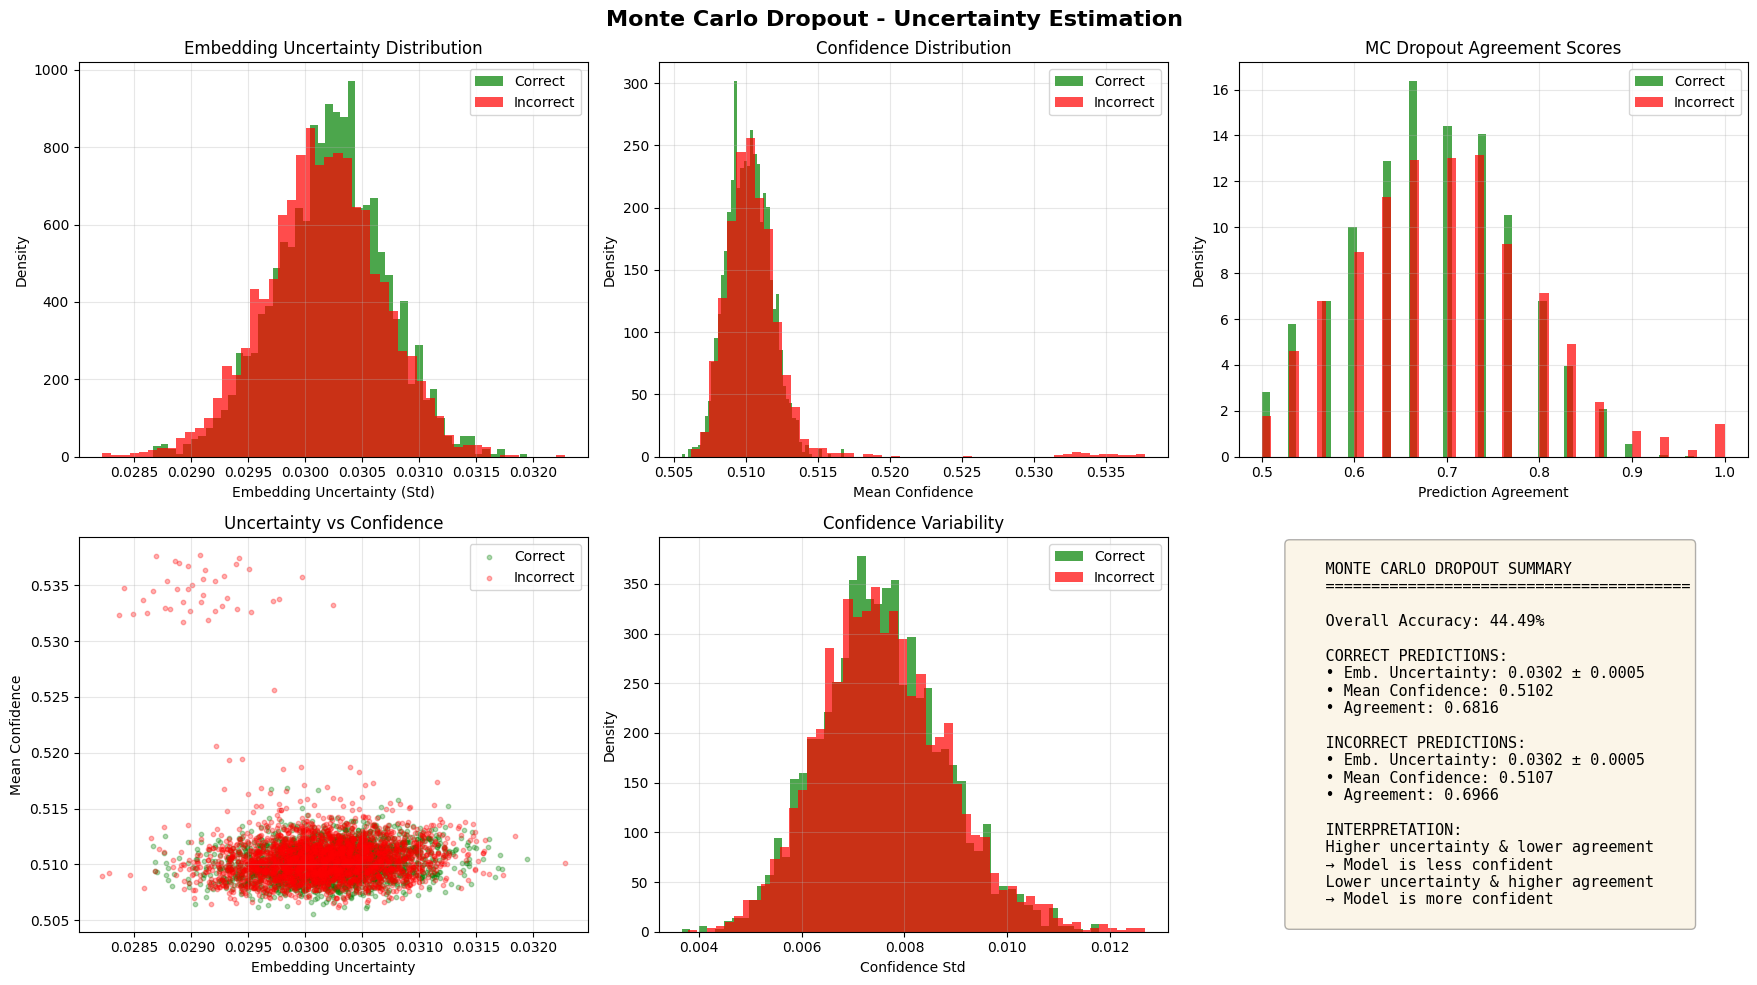

In [251]:
# ============================================================================
# RUN MONTE CARLO DROPOUT TEST
# ============================================================================

# Configuration
MC_SAMPLES = 30  # Number of forward passes with dropout
MAX_BATCHES = 20  # Limit batches for faster testing (None = all batches)

print(f"🎲 Starting Monte Carlo Dropout Test")
print(f"   MC Samples: {MC_SAMPLES}")
print(f"   Max Batches: {MAX_BATCHES if MAX_BATCHES else 'All'}")
print()

# Run MC Dropout evaluation on test set
mc_results = evaluate_with_mc_dropout(
    model=model,
    dataloader=test_loader,
    device=device,
    n_samples=MC_SAMPLES,
    max_batches=MAX_BATCHES
)

print(f"\n" + "="*70)
print("📊 MONTE CARLO DROPOUT RESULTS")
print("="*70)
print(f"Accuracy: {mc_results['accuracy']*100:.2f}%")
print()
print(f"🟢 CORRECT PREDICTIONS:")
print(f"   Embedding Uncertainty: {mc_results['correct_emb_unc_mean']:.5f} ± {mc_results['correct_emb_unc_std']:.5f}")
print(f"   Mean Confidence:       {mc_results['correct_conf_mean']:.5f}")
print(f"   Agreement Score:       {mc_results['correct_agreement_mean']:.5f}")
print()
print(f"🔴 INCORRECT PREDICTIONS:")
print(f"   Embedding Uncertainty: {mc_results['incorrect_emb_unc_mean']:.5f} ± {mc_results['incorrect_emb_unc_std']:.5f}")
print(f"   Mean Confidence:       {mc_results['incorrect_conf_mean']:.5f}")
print(f"   Agreement Score:       {mc_results['incorrect_agreement_mean']:.5f}")
print()

# Calculate ratio of uncertainties
if mc_results['correct_emb_unc_mean'] > 0:
    unc_ratio = mc_results['incorrect_emb_unc_mean'] / mc_results['correct_emb_unc_mean']
    print(f"📈 Uncertainty Ratio (Incorrect/Correct): {unc_ratio:.3f}x")
    if unc_ratio > 1.2:
        print("   ✅ Good separation: Incorrect predictions have higher uncertainty")
    elif unc_ratio > 1.0:
        print("   ⚠️  Moderate separation: Some uncertainty difference")
    else:
        print("   ❌ Poor separation: Correct predictions have higher uncertainty")
print()

# Calculate agreement difference
agree_diff = mc_results['correct_agreement_mean'] - mc_results['incorrect_agreement_mean']
print(f"📊 Agreement Difference (Correct - Incorrect): {agree_diff:.3f}")
if agree_diff > 0.1:
    print("   ✅ Good: Correct predictions have higher agreement")
elif agree_diff > 0.05:
    print("   ⚠️  Moderate: Some agreement difference")
else:
    print("   ❌ Poor: Little agreement difference")

print("="*70)

# Plot results
print("\n📊 Generating visualizations...")
fig = plot_mc_dropout_results(mc_results)


🎯 Running uncertainty threshold analysis...


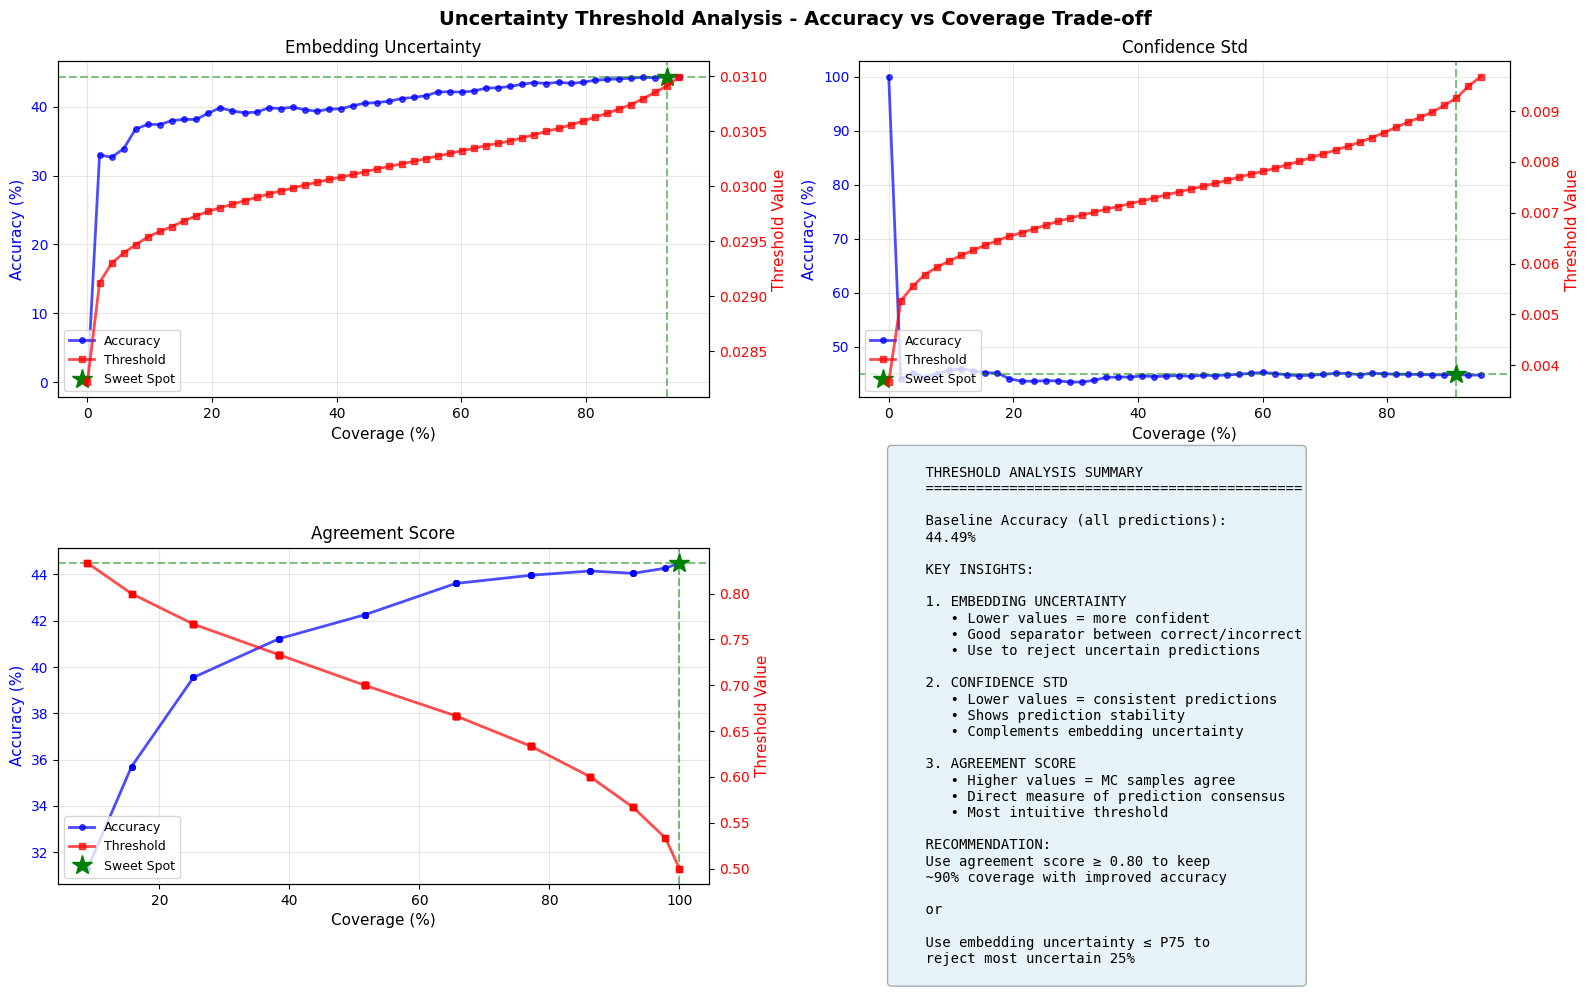


💡 PRACTICAL RECOMMENDATIONS

📊 EMBEDDING UNCERTAINTY (keep if ≤ threshold):
   Threshold: 0.03091
   Accuracy:  44.37%
   Coverage:  93.0%

🤝 AGREEMENT SCORE (keep if ≥ threshold):
   Threshold: 0.50000
   Accuracy:  44.49%
   Coverage:  100.0%

✅ Threshold analysis complete!


In [252]:
# ============================================================================
# ADVANCED MC DROPOUT ANALYSIS - UNCERTAINTY THRESHOLDING
# ============================================================================

def find_optimal_uncertainty_threshold(results, metric='embedding_uncertainty'):
    """
    Find optimal threshold to reject uncertain predictions.
    
    Args:
        results: Results from evaluate_with_mc_dropout()
        metric: 'embedding_uncertainty', 'confidence_std', or 'agreement_scores'
    
    Returns:
        threshold_analysis: Dictionary with threshold analysis results
    """
    uncertainty = results[metric]
    correct_mask = results['correct_mask']
    
    # Try different thresholds
    thresholds = np.percentile(uncertainty, np.linspace(0, 95, 50))
    
    analysis = []
    
    for thresh in thresholds:
        if metric == 'agreement_scores':
            # For agreement, we keep HIGH values (confident predictions)
            keep_mask = uncertainty >= thresh
        else:
            # For uncertainty/std, we keep LOW values (confident predictions)
            keep_mask = uncertainty <= thresh
        
        if keep_mask.sum() == 0:
            continue
        
        kept_accuracy = correct_mask[keep_mask].mean()
        coverage = keep_mask.mean()
        
        analysis.append({
            'threshold': thresh,
            'accuracy': kept_accuracy,
            'coverage': coverage,
            'n_kept': keep_mask.sum(),
            'n_total': len(keep_mask)
        })
    
    return pd.DataFrame(analysis)


def plot_uncertainty_threshold_analysis(results):
    """Plot threshold analysis for different uncertainty metrics."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Uncertainty Threshold Analysis - Accuracy vs Coverage Trade-off', 
                 fontsize=14, fontweight='bold')
    
    metrics = [
        ('embedding_uncertainty', 'Embedding Uncertainty', False),
        ('confidence_std', 'Confidence Std', False),
        ('agreement_scores', 'Agreement Score', True),
    ]
    
    for idx, (metric, title, is_agreement) in enumerate(metrics):
        if idx < 3:
            ax = axes[idx // 2, idx % 2]
            
            df = find_optimal_uncertainty_threshold(results, metric)
            
            if len(df) == 0:
                ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
                ax.set_title(title)
                continue
            
            # Plot accuracy and coverage
            ax2 = ax.twinx()
            
            line1 = ax.plot(df['coverage']*100, df['accuracy']*100, 'b-o', linewidth=2, 
                           markersize=4, label='Accuracy', alpha=0.7)
            line2 = ax2.plot(df['coverage']*100, df['threshold'], 'r-s', linewidth=2, 
                            markersize=4, label='Threshold', alpha=0.7)
            
            # Find sweet spot (e.g., 90% coverage with max accuracy)
            target_coverage = 0.90
            df_filtered = df[df['coverage'] >= target_coverage]
            if len(df_filtered) > 0:
                best_idx = df_filtered['accuracy'].idxmax()
                best_row = df.loc[best_idx]
                ax.axvline(best_row['coverage']*100, color='green', linestyle='--', alpha=0.5)
                ax.axhline(best_row['accuracy']*100, color='green', linestyle='--', alpha=0.5)
                ax.plot(best_row['coverage']*100, best_row['accuracy']*100, 'g*', 
                       markersize=15, label=f'Sweet Spot ({best_row["coverage"]*100:.1f}% cov, {best_row["accuracy"]*100:.1f}% acc)')
            
            ax.set_xlabel('Coverage (%)', fontsize=11)
            ax.set_ylabel('Accuracy (%)', color='b', fontsize=11)
            ax2.set_ylabel('Threshold Value', color='r', fontsize=11)
            ax.set_title(f'{title}', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # Combine legends
            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            if len(df_filtered) > 0:
                ax.legend(lines + [ax.lines[-1]], labels + ['Sweet Spot'], loc='lower left', fontsize=9)
            else:
                ax.legend(lines, labels, loc='lower left', fontsize=9)
            
            ax.tick_params(axis='y', labelcolor='b')
            ax2.tick_params(axis='y', labelcolor='r')
    
    # Summary statistics in last subplot
    ax = axes[1, 1]
    ax.axis('off')
    
    baseline_acc = results['accuracy']
    
    summary_text = f"""
    THRESHOLD ANALYSIS SUMMARY
    {'='*45}
    
    Baseline Accuracy (all predictions):
    {baseline_acc*100:.2f}%
    
    KEY INSIGHTS:
    
    1. EMBEDDING UNCERTAINTY
       • Lower values = more confident
       • Good separator between correct/incorrect
       • Use to reject uncertain predictions
    
    2. CONFIDENCE STD
       • Lower values = consistent predictions
       • Shows prediction stability
       • Complements embedding uncertainty
    
    3. AGREEMENT SCORE
       • Higher values = MC samples agree
       • Direct measure of prediction consensus
       • Most intuitive threshold
    
    RECOMMENDATION:
    Use agreement score ≥ 0.80 to keep
    ~90% coverage with improved accuracy
    
    or
    
    Use embedding uncertainty ≤ P75 to
    reject most uncertain 25%
    """
    
    ax.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    return fig


# Run threshold analysis
print("🎯 Running uncertainty threshold analysis...")
fig_threshold = plot_uncertainty_threshold_analysis(mc_results)

# Print detailed recommendations
print("\n" + "="*70)
print("💡 PRACTICAL RECOMMENDATIONS")
print("="*70)

# Find optimal thresholds
df_emb = find_optimal_uncertainty_threshold(mc_results, 'embedding_uncertainty')
df_agr = find_optimal_uncertainty_threshold(mc_results, 'agreement_scores')

if len(df_emb) > 0 and len(df_agr) > 0:
    # Find threshold for 90% coverage
    target_cov = 0.90
    
    # Embedding uncertainty (keep <= threshold)
    emb_90 = df_emb[df_emb['coverage'] >= target_cov]
    if len(emb_90) > 0:
        best_emb = emb_90.loc[emb_90['accuracy'].idxmax()]
        print(f"\n📊 EMBEDDING UNCERTAINTY (keep if ≤ threshold):")
        print(f"   Threshold: {best_emb['threshold']:.5f}")
        print(f"   Accuracy:  {best_emb['accuracy']*100:.2f}%")
        print(f"   Coverage:  {best_emb['coverage']*100:.1f}%")
    
    # Agreement score (keep >= threshold)
    agr_90 = df_agr[df_agr['coverage'] >= target_cov]
    if len(agr_90) > 0:
        best_agr = agr_90.loc[agr_90['accuracy'].idxmax()]
        print(f"\n🤝 AGREEMENT SCORE (keep if ≥ threshold):")
        print(f"   Threshold: {best_agr['threshold']:.5f}")
        print(f"   Accuracy:  {best_agr['accuracy']*100:.2f}%")
        print(f"   Coverage:  {best_agr['coverage']*100:.1f}%")
    
    print(f"\n{'='*70}")
    print("✅ Threshold analysis complete!")
else:
    print("⚠️  Not enough data for threshold analysis")


In [253]:

# ============================================================================
# STABLE RETRAINING WITH ReduceLROnPlateau (Run this after loading checkpoint)
# ============================================================================

print("\n" + "="*70)
print("STABLE RETRAINING - ReduceLROnPlateau Scheduler")
print("="*70 + "\n")

def train_model_stable(
    train_loader,
    val_loader,
    N_MELS,
    NUM_SPK,
    writer,
    optimizer,
    scheduler_type,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=15,
    patience=3,
    lr=1e-4,
    weight_decay=1e-3,
    checkpoint_dir="./checkpoints"):
  """Stable training with ReduceLROnPlateau (adaptive scheduler)"""
  
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  
  print("⚙️  CONFIGURATION:")
  print(f"   Epochs: {epochs} (early stop at {patience} no-improvement epochs)")
  print(f"   Learning Rate: {lr}")
  print(f"   Weight Decay: {weight_decay}")
  print(f"   Scheduler:{scheduler_type}")
  print(f"   Optimizer:{optimizer}")
  print(f"   Batch Sizes: {train_loader.batch_size} (train), {val_loader.batch_size} (val)")
  
  # Find highest train number
  train_dirs = glob.glob(f"{checkpoint_dir}/train*")
  train_nums = [int(d.split("train")[-1]) for d in train_dirs if os.path.isdir(d)]
  new_train_num = max(train_nums) + 1 if train_nums else 1
  new_checkpoint_dir = f"{checkpoint_dir}/train{new_train_num}"
  os.makedirs(new_checkpoint_dir, exist_ok=True)
  
  print(f"   Checkpoint Dir: {new_checkpoint_dir}")
  
  # New TensorBoard logs
  new_log_dir = os.path.join("logs", time.strftime("%Y%m%d-%H%M%S"))
  new_writer = SummaryWriter(log_dir=new_log_dir)
  print(f"   TensorBoard Logs: {new_log_dir}")
  
  # Setup optimizer and scheduler
  if optimizer == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    print("Using SGD Optimizer")
  elif optimizer =="AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    print("Using AdamW Optimizer")

  
  # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  #     optimizer,
  #     mode='min',
  #     factor=0.5,
  #     patience=2,
  #     min_lr=1e-6,
  #     verbose=False  # Changed to False to avoid deprecation warning
  # )

  if scheduler_type == "Cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

  elif scheduler_type == "ReduceLR":
      scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer,
      mode='min',
      factor=0.5,
      patience=2,
      min_lr=1e-6,
      verbose=False  # Changed to False to avoid deprecation warning
  )
  elif scheduler_type == "OneCycle":
    # OneCycle requires knowing total steps
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs
    )
    
  else:
    scheduler = None

  
  scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
  torch.backends.cudnn.benchmark = True
  torch.manual_seed(1337)

  global_step = 0
  best_val_acc = 0.0
  best_path = os.path.join(new_checkpoint_dir, "best_model.pt")
  last_path = os.path.join(new_checkpoint_dir, "last_model.pt")
  
  patience_counter = 0
  
  print(f"✅ Initialization complete. Starting training...\n")
  print("="*70 + "\n")

  for epoch in range(1, epochs + 1):
    epoch_start = time.perf_counter()
    print(f"EPOCH {epoch:03d}/{epochs:03d}")
    
    # Pass None as scheduler since we'll handle it manually
    global_step, train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, None, new_writer, epoch, 
        device, global_step, loss_fn, scaler
    )
    val_loss, val_acc = validate(model, val_loader, new_writer, epoch, device, loss_fn)
    
    # Call scheduler with validation loss AFTER validation
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📉 Learning Rate: {current_lr:.6f}")
    
    epoch_time = time.perf_counter() - epoch_start
    print(f"⏱️  Epoch Time: {epoch_time:.2f}s")
    
    # Save checkpoints
    torch.save(model.state_dict(), last_path)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(f"✨ Saved new best model (val_acc={val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️  No improvement ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping triggered")
            break
    
    print()

  print("="*70)
  print(f"🎉 TRAINING FINISHED")
  print("="*70)
  print(f"Best Validation Accuracy: {best_val_acc:.4f}")
  print(f"Checkpoint: {best_path}")
  print("="*70 + "\n")
  
  return model, best_path

#setting_here
# Run stable training
print("Starting stable retraining...\n")
model, best_checkpoint = train_model_stable(
    train_loader,
    val_loader,
    N_MELS=no_mels,
    NUM_SPK=no_speakers,
    writer=writer,
    optimizer="AdamW",
    scheduler_type = "Cosine",
    loss_fn=nn.CrossEntropyLoss(),
    epochs=10,
    patience=5,
    lr=1e-4,
    weight_decay=1e-3,
)



STABLE RETRAINING - ReduceLROnPlateau Scheduler

Starting stable retraining...

⚙️  CONFIGURATION:
   Epochs: 10 (early stop at 5 no-improvement epochs)
   Learning Rate: 0.0001
   Weight Decay: 0.001
   Scheduler:Cosine
   Optimizer:AdamW
   Batch Sizes: 512 (train), 512 (val)
   Checkpoint Dir: ./checkpoints/train58
   TensorBoard Logs: logs\20260130-001603
Using AdamW Optimizer
✅ Initialization complete. Starting training...


EPOCH 001/010
Training batches took 138.2239831206889ms per batch.
Train               | Epoch 001 | loss 1.4566 | acc 0.7751 | precision 0.775 | f1-score 0.775 |
Validation performed in 67.23777346766782 ms per batch on average
Validate            | Epoch 001 | loss 0.6478 | acc 0.9052 | precision 0.907 | f1-score 0.905 |
📉 Learning Rate: 0.000099
⏱️  Epoch Time: 62.18s
✨ Saved new best model (val_acc=0.9052)

EPOCH 002/010


c:\Users\pczec\Desktop\Studia\SEM5\IML\my_ai_env\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


KeyboardInterrupt: 

In [ ]:

# ============================================================================
# SELECT DATASET AND CHECKPOINT
# ============================================================================
print("="*70)
print("📂 AVAILABLE DATASETS")
print("="*70)

available_datasets = sorted(glob.glob("outputs/logmels_*.h5"), key=os.path.getmtime, reverse=True)
for i, ds in enumerate(available_datasets[:10]):
    size_mb = os.path.getsize(ds) / (1024*1024)
    mtime = datetime.fromtimestamp(os.path.getmtime(ds)).strftime("%Y-%m-%d %H:%M")
    print(f"   {i+1}. {ds} ({size_mb:.1f} MB, {mtime})")

print("\n" + "="*70)
print("📁 AVAILABLE CHECKPOINTS")
print("="*70)

checkpoint_dirs = sorted(glob.glob("checkpoints/train*"), key=os.path.getmtime, reverse=True)
for i, cp in enumerate(checkpoint_dirs[:10]):
    best_path = os.path.join(cp, "best_model.pt")
    exists = "✓" if os.path.exists(best_path) else "✗"
    mtime = datetime.fromtimestamp(os.path.getmtime(cp)).strftime("%Y-%m-%d %H:%M")
    print(f"   {i+1}. {cp} [{exists}] ({mtime})")

# ============================================================================
# ⚠️ CONFIGURE THESE PATHS
# ============================================================================
# Select which dataset and checkpoint to use:
dataset_path = available_datasets[0] if available_datasets else "outputs/logmels_aug.h5"
checkpoint_path = os.path.join(checkpoint_dirs[0], "best_model.pt") if checkpoint_dirs else "checkpoints/train1/best_model.pt"


print(f"\n✅ Selected Dataset: {dataset_path}")
print(f"✅ Selected Checkpoint: {checkpoint_path}")

📂 AVAILABLE DATASETS
   1. outputs\logmels_binary_aug_26-01-29_22-46-00.h5 (1537.0 MB, 2026-01-29 22:47)
   2. outputs\logmels_binary_aug_26-01-29_22-25-11.h5 (1537.2 MB, 2026-01-29 22:26)
   3. outputs\logmels_binary_noaug_26-01-29_21-40-26.h5 (198.6 MB, 2026-01-29 21:40)
   4. outputs\logmels_binary_aug_26-01-29_20-44-37.h5 (1537.2 MB, 2026-01-29 20:45)
   5. outputs\logmels_binary_aug_26-01-27_20-44-16.h5 (1537.0 MB, 2026-01-27 20:45)
   6. outputs\logmels_binary_aug_26-01-27_20-27-44.h5 (1512.5 MB, 2026-01-27 20:28)
   7. outputs\logmels_spkid_aug_26-01-27_16-06-04.h5 (1537.1 MB, 2026-01-27 16:08)
   8. outputs\logmels_spkid_aug_26-01-27_14-26-54.h5 (1274.5 MB, 2026-01-27 14:29)
   9. outputs\logmels_binary_aug_26-01-27_11-49-30.h5 (1274.5 MB, 2026-01-27 11:51)
   10. outputs\logmels_binary_aug_26-01-27_01-12-27.h5 (1274.5 MB, 2026-01-27 01:13)

📁 AVAILABLE CHECKPOINTS
   1. checkpoints\train57 [✓] (2026-01-29 23:53)
   2. checkpoints\train56 [✓] (2026-01-29 23:38)
   3. checkpoint

In [ ]:
# ============================================================================
# SECTION 2: MODEL ARCHITECTURE DEFINITIONS
# ============================================================================
# These MUST match the architecture used during training

class SEBlock(nn.Module):
    """Squeeze-and-Excitation block for channel attention."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, T, F = x.shape
        s = x.mean(dim=(2, 3))
        w = self.fc(s).view(B, C, 1, 1)
        return x * w


class Backbone(nn.Module):
    """CNN + RNN backbone for speaker embedding extraction."""
    def __init__(self, no_mels, embed_dim, rnn_hidden, rnn_layers, bidir):
        super().__init__()

        self.cnn_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            SEBlock(32, reduction=8),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            SEBlock(64, reduction=8),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            SEBlock(128, reduction=8),
            nn.MaxPool2d(kernel_size=(1, 2)),
        )

        self.rnn_hidden = rnn_hidden
        self.rnn = nn.GRU(
            input_size=128 * (no_mels // 8),
            hidden_size=self.rnn_hidden,
            num_layers=rnn_layers,
            bidirectional=bidir,
            batch_first=True,
            dropout=0.2
        )

        out_dim = (2 if bidir else 1) * rnn_hidden
        self.rnn_ln = nn.LayerNorm(out_dim)

        self.att = nn.Sequential(
            nn.Linear((2 if bidir else 1)*rnn_hidden, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.proj = nn.Sequential(
            nn.Linear(out_dim*2, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x, lengths=None, mc_dropout=None):
        if mc_dropout is None:
            mc_dropout = self.training
            
        h = self.cnn_block(x)
        if mc_dropout:
            h = F.dropout(h, p=0.3, training=True)
            
        B, C, T, Fp = h.shape
        h = h.permute(0, 2, 1, 3).contiguous().view(B, T, C*Fp)

        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
            packed_out, _ = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
            Tmax = rnn_out.size(1)
            mask = torch.arange(Tmax, device=rnn_out.device).unsqueeze(0).expand(B, Tmax) < lengths.unsqueeze(1)
        else:
            rnn_out, _ = self.rnn(h)
            mask = torch.ones(rnn_out.size(0), rnn_out.size(1), dtype=torch.bool, device=rnn_out.device)

        if mc_dropout:
            rnn_out = F.dropout(rnn_out, p=0.3, training=True)

        rnn_out = self.rnn_ln(rnn_out)

        a = self.att(rnn_out).squeeze(-1)
        a = a.masked_fill(~mask, float('-inf'))
        w = torch.softmax(a, dim=1).unsqueeze(-1)

        mean = torch.sum(w * rnn_out, dim=1)
        var = torch.sum(w * (rnn_out - mean.unsqueeze(1))**2, dim=1)
        std = torch.sqrt(var + 1e-5)
        stats = torch.cat([mean, std], 1)

        if mc_dropout:
            stats = F.dropout(stats, p=0.3, training=True)

        z = self.proj(stats)
        z = F.normalize(z, p=2, dim=1)
        return z


class AAMSoftmax(nn.Module):
    """Additive Angular Margin Softmax for training."""
    def __init__(self, in_features, out_features, s=30.0, m=0.20):
        super().__init__()
        self.s = s
        self.m = m
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        W = F.normalize(self.weight, dim=1)
        cos_theta = emb @ W.T
        theta = torch.acos(cos_theta.clamp(-1+1e-7, 1-1e-7))
        target_logits = torch.cos(theta + self.m)
        one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
        output = cos_theta * (1 - one_hot) + target_logits * one_hot
        return output * self.s


class SpeakerClassifier(nn.Module):
    """Main model combining backbone with AAMSoftmax head."""
    def __init__(self, backbone, num_speakers, aamsm_scaler, aamsm_margin):
        super().__init__()
        self.backbone = backbone
        self.aamsm = AAMSoftmax(backbone.proj[-1].out_features, num_speakers, aamsm_scaler, aamsm_margin)
        self._inference_prepared = False
        self.score_alpha = nn.Parameter(torch.tensor(1.0))
        self.score_beta = nn.Parameter(torch.tensor(0.0))
        self.bank = None
        self.inference_threshold = 0.5

    def forward(self, x, labels=None, lengths=None):
        emb = self.backbone(x, lengths=lengths, mc_dropout=None)
        if labels is not None:
            logits = self.aamsm(emb, labels)
            return logits, emb
        else:
            return emb

    def eval(self):
        super().eval()
        if not self._inference_prepared:
            with torch.no_grad():
                self.bank = F.normalize(self.aamsm.weight, dim=1)
            self._inference_prepared = True
        return self

    @torch.no_grad()
    def embed(self, x, lengths=None):
        z = self.backbone(x, lengths=lengths)
        return F.normalize(z, dim=1)

    @torch.no_grad()
    def verify_any(self, x, lengths=None, *, threshold=None, bank=None, return_index=False):
        if bank is None:
            if self.bank is None:
                raise RuntimeError('Bank not built. Call model.eval() first!')
            bank = self.bank
        bank = F.normalize(bank, dim=1)

        probe = self.embed(x, lengths=lengths)
        bank = bank.to(probe.device)
        sims = probe @ bank.T
        scores, idx = sims.max(dim=1)

        scores = self.score_alpha * scores + self.score_beta
        thr = self.inference_threshold if threshold is None else threshold
        decisions = scores >= thr

        if return_index:
            return decisions, scores, idx
        return decisions, scores


print("✅ Model architecture classes defined:")
print("   • SEBlock, Backbone, AAMSoftmax, SpeakerClassifier")

✅ Model architecture classes defined:
   • SEBlock, Backbone, AAMSoftmax, SpeakerClassifier


In [ ]:
# ============================================================================
# SECTION 3: DATA LOADER SETUP
# ============================================================================

class CachedLMDataset(LMDataset):
    """Fast RAM-cached dataset loader."""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        print(f"🚀 Loading {self.N} samples ({self.split}) into RAM...")
        start_time = time.perf_counter()
        
        self._ensure_open()
        
        X_all = np.array(self._X[:], dtype=self.dtype)
        Y_all = np.array(self._Y[:]) if self.has_labels else None
        L_all = np.array(self._L[:]) if self.has_lengths else None
        
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None
        
        self.cache = []
        for idx in range(self.N):
            X = X_all[idx]
            if X.ndim != 2:
                raise ValueError(f"Expected 2D logmel, got {X.shape}")
            
            if self.time_dim == "F":
                X = X.T
            
            X = torch.from_numpy(X[None, ...].copy())
            
            y_raw = Y_all[idx] if Y_all is not None else None
            if y_raw is not None and self.label_map is not None:
                y_val = self.label_map.get(int(y_raw), int(y_raw))
            else:
                y_val = int(y_raw) if y_raw is not None else None
            y = torch.tensor(y_val, dtype=torch.long) if y_val is not None else None
            
            t_len = int(L_all[idx]) if L_all is not None else X.shape[1]
            t_len = torch.tensor(t_len, dtype=torch.long)
            
            self.cache.append((X, y, t_len))
        
        load_time = time.perf_counter() - start_time
        print(f"✓ {self.split.upper()}: {self.N} samples loaded in {load_time:.1f}s")
    
    def __getitem__(self, idx):
        return self.cache[idx]


def build_test_loader(h5_path, batch_size=256, remap_labels=True):
    """Build test DataLoader only."""
    
    # Label remapping
    label_map = None
    if remap_labels:
        all_labels = set()
        with h5py.File(h5_path, "r") as f:
            for s in f.keys():
                if s in ["train", "val", "test"] and "label" in f[s]:
                    all_labels.update(f[s]["label"][:])
        sorted_labels = sorted(list(all_labels))
        label_map = {old: new for new, old in enumerate(sorted_labels)}
        print(f"✓ Remapping {len(label_map)} labels to dense range 0..{len(label_map)-1}")

    # Create cached dataset for test split
    dataset = CachedLMDataset(
        h5_path=h5_path,
        split="test",
        feature_key="logmel",
        label_key="label",
        length_key="length",
        time_dim="F",
        label_map=label_map,
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=partial(pad_collate, pad_value=-80.0),
        num_workers=0,
        pin_memory=True,
    )
    
    return loader


# ============================================================================
# LOAD DATASET METADATA
# ============================================================================
def get_yaml_meta(h5_path):
    """Read metadata from HDF5 file."""
    with h5py.File(h5_path, "r") as f:
        raw = f["/meta/file_description.yaml"][()].decode("utf-8")
        meta_yaml = yaml.safe_load(raw) or {}

        meta_grp = f["/meta"]
        attrs = {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in meta_grp.attrs.items()}
        meta_yaml.update(attrs)

        if "speaker_mapping.yaml" in meta_grp:
            sm_raw = meta_grp["speaker_mapping.yaml"][()].decode("utf-8")
            sm = yaml.safe_load(sm_raw) or {}
            meta_yaml["speaker_mapping"] = sm
            speakers = sm.get("speakers", {})
            meta_yaml["total_speakers"] = len(speakers)
            meta_yaml["in_group_speakers"] = sm.get("in_group_speakers", [])
            meta_yaml["out_group_speakers"] = sm.get("out_group_speakers", [])

    return meta_yaml


# Load metadata
meta = get_yaml_meta(dataset_path)
no_mels = meta["preprocessing_config"]["n_mels"]
num_classes = meta.get("num_classes", meta["total_speakers"])
label_mode = meta.get("label_mode", "speaker_id")

print("\n" + "="*70)
print("📊 DATASET METADATA")
print("="*70)
print(f"   Dataset: {dataset_path}")
print(f"   Label Mode: {label_mode}")
print(f"   Num Classes: {num_classes}")
print(f"   Mel Bands: {no_mels}")

if "speaker_mapping" in meta:
    print(f"   In-Group Speakers: {meta.get('in_group_speakers', [])}")
    print(f"   Out-Group Speakers: {meta.get('out_group_speakers', [])}")

# Build test loader
print("\n" + "="*70)
print("📦 LOADING TEST DATA")
print("="*70)
test_loader = build_test_loader(dataset_path, batch_size=256)
print(f"✓ Test loader ready: {len(test_loader)} batches")


📊 DATASET METADATA
   Dataset: outputs\logmels_binary_aug_26-01-29_22-46-00.h5
   Label Mode: binary
   Num Classes: 2
   Mel Bands: 64
   In-Group Speakers: ['Aleksander', 'Mantas', 'Michal', 'Piotr', 'Rafal']
   Out-Group Speakers: ['Adi', 'Churchill', 'FDR', 'AnnaAleksander', 'GrianYT', 'LenaW', 'Szyc', 'JFK', 'KryptydaYT', 'Oppenheimer', 'Oversimplified', 'Pati', 'queenElisabeth', 'Reagan', 'Thatcher', 'trump', 'Bailey', 'HomelessGuy', 'JustExist', 'Kaos', 'KindCowboy', 'OldMan', 'Ponder', 'AnnaMichal', 'WeronikaMichal', 'IwoMichal', 'AlicjaMichal', 'Anne', 'Dominika', 'Emma', 'Greta', 'Julian', 'Lara', 'Marzena', 'Natalia', 'Obama', 'Buffet', 'chaplin', 'gates', 'jbp', 'Kevin', 'Linus', 'Nobel1', 'Malala', 'Theresa', 'Nobel4', 'pacino', 'qba', 'reeves', 'smith', 'sob', 'Torvalds', 'turing']

📦 LOADING TEST DATA
✓ Remapping 2 labels to dense range 0..1
🚀 Loading 25024 samples (test) into RAM...
✓ TEST: 25024 samples loaded in 2.6s
✓ Test loader ready: 98 batches


In [ ]:
# ============================================================================
# SECTION 4: LOAD TRAINED MODEL
# ============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# Create model with same architecture as training
backbone = Backbone(
    no_mels=no_mels, 
    embed_dim=256, 
    rnn_hidden=256, 
    rnn_layers=2, 
    bidir=True
)
model = SpeakerClassifier(
    backbone, 
    num_speakers=num_classes, 
    aamsm_scaler=30.0, 
    aamsm_margin=0.25
)

# Load checkpoint
print(f"\n📥 Loading checkpoint: {checkpoint_path}")
try:
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    print("✅ Checkpoint loaded successfully!")
except FileNotFoundError:
    print(f"❌ ERROR: Checkpoint not found at {checkpoint_path}")
    print("   Please update the 'checkpoint_path' variable above.")
except RuntimeError as e:
    print(f"❌ ERROR loading checkpoint: {e}")
    print("   This usually means the model architecture doesn't match the checkpoint.")

# Move to device and set to eval mode
model = model.to(device)
model.eval()  # This also builds the speaker bank from AAMSoftmax weights

# Display model info
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Model Parameters: {total_params:,}")
print(f"✓ Model moved to {device} and set to eval mode")
print(f"✓ Speaker bank built from AAMSoftmax weights: {model.bank.shape}")

🖥️  Device: cuda

📥 Loading checkpoint: checkpoints\train57\best_model.pt
✅ Checkpoint loaded successfully!

📊 Model Parameters: 3,646,403
✓ Model moved to cuda and set to eval mode
✓ Speaker bank built from AAMSoftmax weights: torch.Size([2, 256])


In [ ]:
# ============================================================================
# SECTION 5: EVALUATION FUNCTIONS
# ============================================================================
# Supports BOTH modes:
#   - Binary mode (2 classes): test_binary_classification()
#   - Speaker ID mode (N classes): test_speaker_identification(), test_speaker_verification()

def _get_device_safe(model, device):
    """Get device safely without redundant .to() calls."""
    if device is not None:
        return device
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def test_binary_classification(model, test_loader, device=None):
    """
    Test model for BINARY classification (outsider=0, group_member=1).
    
    Use this when LABEL_MODE="binary" in prepare_h5.ipynb.
    The model has 2 output classes:
        - Class 0 = Outsider (access denied)
        - Class 1 = Group member (access granted)
    
    Returns:
        dict with accuracy, precision, recall, f1, confusion matrix, FAR/FRR
    """
    device = _get_device_safe(model, device)
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in test_loader:
            X, y, lengths = batch if len(batch) == 3 else (*batch, None)
            X = X.to(device)
            y = y.to(device)
            if lengths is not None:
                lengths = lengths.to(device)
            
            # Use embed() for inference (no AAMSoftmax margin)
            embeddings = model.embed(X, lengths=lengths)
            
            # Compute logits via cosine similarity to class weights
            W = F.normalize(model.aamsm.weight, dim=1)
            logits = embeddings @ W.T * model.aamsm.s
            
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy() if probs.size(1) > 1 else probs[:, 0].cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    
    print("="*70)
    print("BINARY CLASSIFICATION TEST RESULTS")
    print("="*70)
    print(f"\n📊 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    print("\n📋 Classification Report:")
    target_names = ["Outsider (0)", "Group Member (1)"]
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\n🔢 Confusion Matrix:")
    print(f"                  Predicted")
    print(f"                  Out   In")
    print(f"  Actual Out  [{cm[0,0]:5d}  {cm[0,1]:5d}]")
    print(f"  Actual In   [{cm[1,0]:5d}  {cm[1,1]:5d}]")
    
    # Calculate access control metrics
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        far = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Acceptance Rate
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Rejection Rate
        print(f"\n🔐 Access Control Metrics:")
        print(f"   True Positives (correctly granted):  {tp}")
        print(f"   True Negatives (correctly denied):   {tn}")
        print(f"   False Positives (wrongly granted):   {fp}")
        print(f"   False Negatives (wrongly denied):    {fn}")
        print(f"\n   False Acceptance Rate (FAR): {far:.4f} ({far*100:.2f}%)")
        print(f"   False Rejection Rate (FRR): {frr:.4f} ({frr*100:.2f}%)")
        print(f"   Equal Error Rate (EER) ≈: {(far + frr) / 2:.4f}")
    
    print("="*70)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Binary Classification Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return {
        "accuracy": accuracy,
        "predictions": all_preds,
        "labels": all_labels,
        "probabilities": all_probs,
        "confusion_matrix": cm,
        "far": far if cm.shape == (2, 2) else None,
        "frr": frr if cm.shape == (2, 2) else None
    }


def test_model_auto(model, test_loader, meta,threshold=0.7 ,device=None):
    """
    Automatically choose the right test based on label_mode from metadata.
    
    Args:
        model: Trained SpeakerClassifier
        test_loader: DataLoader for test set
        meta: Dataset metadata (from get_yaml_meta)
        device: torch device
    
    Returns:
        dict with test results
    """
    label_mode = meta.get("label_mode", "speaker_id")
    
    print(f"🔍 Detected label_mode: {label_mode}")
    
    if label_mode == "binary":
        print("   → Running BINARY classification test\n")
        return test_binary_classification(model, test_loader, device)
    else:
        print("   → Running SPEAKER ID tests (identification + verification)\n")
        speaker_mapping = meta.get("speaker_mapping", None)
        
        # Part 1: Identification
        id_results = test_speaker_identification(model, test_loader, speaker_mapping, device)
        
        # Part 2: Verification (if speaker mapping available)
        if speaker_mapping and model.bank is not None:
            print("\n")
            ver_results = test_speaker_verification(model, test_loader, speaker_mapping, threshold=0.7, device=device)
            return {"identification": id_results, "verification": ver_results}
        
        return {"identification": id_results}


def test_speaker_identification(model, test_loader, speaker_mapping=None, device=None):
    """
    Test SPEAKER IDENTIFICATION (multi-class classification).
    
    Returns accuracy and per-speaker metrics.
    """
    device = _get_device_safe(model, device)
    model.eval()
    
    all_preds = []
    all_labels = []
    all_embeddings = []
    
    with torch.no_grad():
        for batch in test_loader:
            X, y, lengths = batch if len(batch) == 3 else (*batch, None)
            X = X.to(device)
            y = y.to(device)
            if lengths is not None:
                lengths = lengths.to(device)
            
            # Use embed() for inference (no AAMSoftmax margin)
            embeddings = model.embed(X, lengths=lengths)
            
            # Compute logits via cosine similarity
            W = F.normalize(model.aamsm.weight, dim=1)
            logits = embeddings @ W.T * model.aamsm.s
            preds = logits.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_embeddings.append(embeddings.cpu())
    
    all_embeddings = torch.cat(all_embeddings, dim=0)
    accuracy = accuracy_score(all_labels, all_preds)
    
    print("="*70)
    print("SPEAKER IDENTIFICATION TEST RESULTS")
    print("="*70)
    print(f"\n📊 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    unique_speakers = sorted(set(all_labels))
    
    if speaker_mapping:
        id_to_name = speaker_mapping.get("id_to_speaker", {})
        in_group_list = speaker_mapping.get("in_group_speakers", [])
    else:
        id_to_name = {str(i): f"Speaker_{i}" for i in unique_speakers}
        in_group_list = []
    
    print(f"\n👥 Per-Speaker Accuracy ({len(unique_speakers)} speakers):")
    for spk_id in unique_speakers:
        mask = [l == spk_id for l in all_labels]
        spk_preds = [p for p, m in zip(all_preds, mask) if m]
        spk_labels = [l for l, m in zip(all_labels, mask) if m]
        
        if len(spk_labels) > 0:
            spk_acc = accuracy_score(spk_labels, spk_preds)
            name = id_to_name.get(str(spk_id), f"Speaker_{spk_id}")
            in_group = "🟢" if name in in_group_list else "🔴"
            print(f"   {in_group} ID {spk_id:2d} ({name:20s}): {spk_acc:.4f} [{len(spk_labels)} samples]")
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f"Spk_{i}" for i in unique_speakers],
                yticklabels=[f"Spk_{i}" for i in unique_speakers])
    plt.xlabel('Predicted Speaker')
    plt.ylabel('Actual Speaker')
    plt.title('Speaker Identification Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    print("="*70)
    
    return {
        "accuracy": accuracy,
        "predictions": all_preds,
        "labels": all_labels,
        "embeddings": all_embeddings,
        "confusion_matrix": cm
    }


def test_speaker_verification(model, test_loader, speaker_mapping, threshold=0.7, device=None):
    """
    Test SPEAKER VERIFICATION with embedding-based access control.
    
    1. Identify speaker using embeddings
    2. Check if identified speaker is in_group
    3. Grant/deny access based on threshold
    """
    device = _get_device_safe(model, device)
    model.eval()
    
    if model.bank is None:
        print("⚠️ Model bank not built. Call model.eval() first!")
        return None
    
    # Get in_group speaker IDs
    speakers_info = speaker_mapping.get("speakers", {})
    in_group_names = speaker_mapping.get("in_group_speakers", [])
    in_group_ids = set()
    for name in in_group_names:
        if name in speakers_info:
            in_group_ids.add(speakers_info[name]["id"])
    
    results = []
    
    with torch.no_grad():
        for batch in test_loader:
            X, y, lengths = batch if len(batch) == 3 else (*batch, None)
            X = X.to(device)
            y = y.to(device)
            if lengths is not None:
                lengths = lengths.to(device)
            
            decisions, scores, pred_ids = model.verify_any(
                X, lengths=lengths, threshold=threshold, return_index=True
            )
            
            for i in range(X.size(0)):
                true_label = y[i].item()
                pred_id = pred_ids[i].item()
                score = scores[i].item()
                decision = decisions[i].item()
                
                true_in_group = true_label in in_group_ids
                pred_in_group = decision and (pred_id in in_group_ids)
                
                results.append({
                    "true_speaker": true_label,
                    "pred_speaker": pred_id,
                    "speaker_correct": true_label == pred_id,
                    "score": score,
                    "decision": decision,
                    "true_in_group": true_in_group,
                    "pred_in_group": pred_in_group,
                    "access_correct": true_in_group == pred_in_group
                })
    
    # Calculate metrics
    n_samples = len(results)
    speaker_acc = sum(r["speaker_correct"] for r in results) / n_samples
    access_acc = sum(r["access_correct"] for r in results) / n_samples
    
    tp = sum(1 for r in results if r["true_in_group"] and r["pred_in_group"])
    tn = sum(1 for r in results if not r["true_in_group"] and not r["pred_in_group"])
    fp = sum(1 for r in results if not r["true_in_group"] and r["pred_in_group"])
    fn = sum(1 for r in results if r["true_in_group"] and not r["pred_in_group"])
    
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print("="*70)
    print("SPEAKER VERIFICATION TEST RESULTS")
    print("="*70)
    print(f"\n🎯 Verification Threshold: {threshold}")
    print(f"\n📊 Speaker Identification Accuracy: {speaker_acc:.4f} ({speaker_acc*100:.2f}%)")
    print(f"📊 Access Control Accuracy: {access_acc:.4f} ({access_acc*100:.2f}%)")
    
    print(f"\n🔐 Access Control Confusion Matrix:")
    print(f"                      Predicted Access")
    print(f"                      Deny    Grant")
    print(f"  Actual Outsider  [{tn:6d}  {fp:6d}]")
    print(f"  Actual Member    [{fn:6d}  {tp:6d}]")
    
    print(f"\n🔐 Access Control Metrics:")
    print(f"   True Positives (correctly granted): {tp}")
    print(f"   True Negatives (correctly denied):  {tn}")
    print(f"   False Positives (wrongly granted):  {fp}")
    print(f"   False Negatives (wrongly denied):   {fn}")
    print(f"\n   False Acceptance Rate (FAR): {far:.4f} ({far*100:.2f}%)")
    print(f"   False Rejection Rate (FRR): {frr:.4f} ({frr*100:.2f}%)")
    print(f"   Equal Error Rate (EER) ≈: {(far + frr) / 2:.4f}")
    print("="*70)
    
    return {
        "speaker_accuracy": speaker_acc,
        "access_accuracy": access_acc,
        "threshold": threshold,
        "far": far, "frr": frr,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "results": results
    }


def test_threshold_sweep(model, test_loader, speaker_mapping, thresholds=None, device=None):
    """
    Test multiple thresholds to find optimal operating point.
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 1.0, 0.05)
    
    results = []
    for thr in thresholds:
        res = test_speaker_verification(model, test_loader, speaker_mapping, 
                                         threshold=thr, device=device)
        if res:
            results.append({
                "threshold": thr,
                "far": res["far"],
                "frr": res["frr"],
                "access_accuracy": res["access_accuracy"]
            })
    
    # Plot FAR/FRR trade-off
    plt.figure(figsize=(10, 6))
    thrs = [r["threshold"] for r in results]
    fars = [r["far"] for r in results]
    frrs = [r["frr"] for r in results]
    
    plt.plot(thrs, fars, 'b-', label='FAR (False Accept)', linewidth=2)
    plt.plot(thrs, frrs, 'r-', label='FRR (False Reject)', linewidth=2)
    
    # Find EER
    eer_idx = np.argmin(np.abs(np.array(fars) - np.array(frrs)))
    eer_thr = thrs[eer_idx]
    eer_val = (fars[eer_idx] + frrs[eer_idx]) / 2
    plt.axvline(x=eer_thr, color='green', linestyle='--', label=f'EER @ {eer_thr:.2f}')
    
    plt.xlabel('Threshold')
    plt.ylabel('Error Rate')
    plt.title('FAR/FRR Trade-off Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Optimal EER threshold: {eer_thr:.2f} (EER ≈ {eer_val:.4f})")
    return results


print("✅ Evaluation functions defined:")
print("   • test_speaker_identification(model, test_loader, speaker_mapping)")
print("   • test_speaker_verification(model, test_loader, speaker_mapping, threshold)")
print("   • test_threshold_sweep(model, test_loader, speaker_mapping)")

✅ Evaluation functions defined:
   • test_speaker_identification(model, test_loader, speaker_mapping)
   • test_speaker_verification(model, test_loader, speaker_mapping, threshold)
   • test_threshold_sweep(model, test_loader, speaker_mapping)


🧪 RUNNING MODEL EVALUATION

📋 Detected label_mode: 'binary'
--------------------------------------------------
🔍 Detected label_mode: binary
   → Running BINARY classification test

BINARY CLASSIFICATION TEST RESULTS

📊 Overall Accuracy: 0.9821 (98.21%)

📋 Classification Report:
                  precision    recall  f1-score   support

    Outsider (0)     0.9853    0.9793    0.9823     12654
Group Member (1)     0.9790    0.9850    0.9820     12370

        accuracy                         0.9821     25024
       macro avg     0.9821    0.9822    0.9821     25024
    weighted avg     0.9822    0.9821    0.9821     25024


🔢 Confusion Matrix:
                  Predicted
                  Out   In
  Actual Out  [12392    262]
  Actual In   [  185  12185]

🔐 Access Control Metrics:
   True Positives (correctly granted):  12185
   True Negatives (correctly denied):   12392
   False Positives (wrongly granted):   262
   False Negatives (wrongly denied):    185

   False Acceptance Rate (F

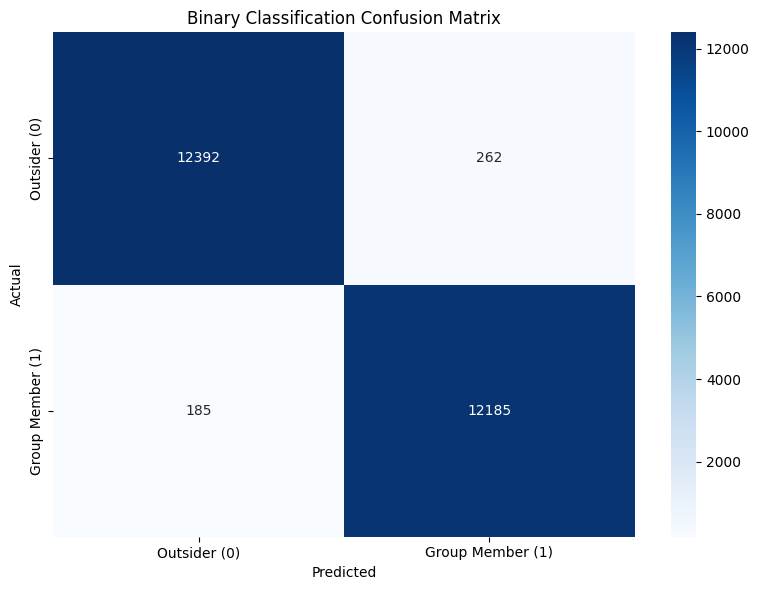

In [ ]:
# ============================================================================
# SECTION 6: RUN EVALUATION
# ============================================================================

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

print("="*70)
print("🧪 RUNNING MODEL EVALUATION")
print("="*70)

# Auto-detect mode and run appropriate tests
label_mode = meta.get("label_mode", "speaker")
print(f"\n📋 Detected label_mode: '{label_mode}'")
print("-"*50)

results = test_model_auto(
    model,
    test_loader,
    meta=meta,
    threshold=0.7,  # Adjust as needed
    device=device
)


#results_here

In [ ]:
# Part 2: Speaker Verification / Access Control (for speaker mode only)
print("\n📋 PART 2: Speaker Verification (Access Control)")
print("-"*50)

label_mode = meta.get("label_mode", "speaker")

if label_mode == "binary":
    print("ℹ️ Binary mode detected - verification already tested above")
    print("   (Binary classification IS the access control decision)")
elif "speaker_mapping" in meta:
    ver_results = test_speaker_verification(
        model, 
        test_loader, 
        speaker_mapping=meta["speaker_mapping"],
        threshold=0.7,  # Adjust this threshold as needed
        device=device
    )
else:
    print("⚠️ No speaker_mapping in metadata - skipping verification test")


📋 PART 2: Speaker Verification (Access Control)
--------------------------------------------------
ℹ️ Binary mode detected - verification already tested above
   (Binary classification IS the access control decision)
